# Import & Helpers

In [76]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers: dataframe shaping / printing / plotting
# ============================================================

def _is_q0_vec(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return bool(np.allclose(q, 0.0, atol=tol, rtol=0.0))


def _scores_at_qindex(df, q_index, value_col, channels_order=CHANNELS_ORDER):
    sub = df[df["Q_index"] == int(q_index)]
    out = {}
    for ch in channels_order:
        ss = sub[sub["channel"] == ch]
        out[ch] = float(ss.iloc[0][value_col]) if len(ss) else np.nan
    return out


def _leading_row(df, value_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(value_col, ascending=False).iloc[0]


def _format_channel_scores(score_map, channels_order=CHANNELS_ORDER):
    parts = []
    for ch in channels_order:
        val = score_map.get(ch, np.nan)
        if np.isfinite(val):
            parts.append(f"{ch}={val:.3e}")
        else:
            parts.append(f"{ch}=nan")
    return ", ".join(parts)


def _append_step_rows(storage, df, *, step_index, T, family):
    for _, row in df.iterrows():
        storage.append({
            "family": family,  # "kernel" or "instability"
            "step_index": int(step_index),
            "T": float(T),
            "Q_index": int(row["Q_index"]),
            "Q": np.asarray(row["Q"], dtype=float),
            "Qx": float(row["Qx"]),
            "Qy": float(row["Qy"]),
            "channel": str(row["channel"]),
            "value": float(row["physical_score"] if family == "kernel" else row["score"]),
        })


def _collapse_q_groups(history_df, *, q0_tol=1e-10):
    """
    Collapse selected Qs into two groups:
      - Q0 : exact q=0
      - QM : max over all nonzero selected Q's
    """
    rows = []
    for (family, step_index, T, channel), sub in history_df.groupby(["family", "step_index", "T", "channel"]):
        sub = sub.copy()
        q0_mask = sub["Q"].apply(lambda x: _is_q0_vec(x, tol=q0_tol)).values

        # Q=0
        sub_q0 = sub[q0_mask]
        q0_val = np.nan
        if len(sub_q0):
            q0_val = float(np.max(sub_q0["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "Q0",
            "value": q0_val,
        })

        # Q=M group = max over all nonzero chosen Qs
        sub_qm = sub[~q0_mask]
        qm_val = np.nan
        if len(sub_qm):
            qm_val = float(np.max(sub_qm["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "QM",
            "value": qm_val,
        })

    out = pd.DataFrame(rows).sort_values(["family", "Q_group", "step_index", "channel"]).reset_index(drop=True)
    return out


def plot_flow_group_curves(
    grouped_df,
    *,
    last_n_steps=None,
    ylog=True,
    title_prefix="RG flow",
    ylim=1e-2
):
    """
    Produce exactly 4 plots:
      1. Q=0 kernel score vs T
      2. Q=M kernel score vs T
      3. Q=0 instability score vs T
      4. Q=M instability score vs T
    """
    df = grouped_df.copy()

    if last_n_steps is not None:
        keep_steps = sorted(df["step_index"].unique())[-int(last_n_steps):]
        df = df[df["step_index"].isin(keep_steps)].copy()

    panels = [
        ("kernel", "Q0", "sign-aware kernel score"),
        ("kernel", "QM", "sign-aware kernel score"),
        ("instability", "Q0", "physical instability score"),
        ("instability", "QM", "physical instability score"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (family, q_group, ylabel) in zip(axes, panels):
        sub = df[(df["family"] == family) & (df["Q_group"] == q_group)].copy()

        for ch in CHANNELS_ORDER:
            ss = sub[sub["channel"] == ch].sort_values("step_index")
            if len(ss) == 0:
                continue

            y = ss["value"].to_numpy(dtype=float)
            x = ss["T"].to_numpy(dtype=float)

            if ylog:
                y = np.where(y > 0, y, np.nan)
                ax.set_yscale("log")

            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=ch)

        ax.set_title(f"{title_prefix}: {family} / {q_group}")
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_flow_step_summary(
    *,
    step_index,
    T,
    rhs_norm,
    signaware_df,
    instab_df,
):
    lead_kernel = _leading_row(signaware_df, "physical_score")
    lead_instab = _leading_row(instab_df, "score")

    lead_qi_kernel = int(lead_kernel["Q_index"])
    lead_qi_instab = int(lead_instab["Q_index"])

    kernel_scores_at_leadQ = _scores_at_qindex(signaware_df, lead_qi_kernel, "physical_score")
    instab_scores_at_leadQ = _scores_at_qindex(instab_df, lead_qi_instab, "score")

    print(
        f"step={step_index:4d} | "
        f"T={T:.6f} | rhs_norm={rhs_norm:.3e} | "
        f"lead_kernel={lead_kernel['channel']} @ Q{lead_qi_kernel}:{fmt_q(lead_kernel['Q'])} "
        f"score={float(lead_kernel['physical_score']):.3e}"
    )
    print("kernel scores:", _format_channel_scores(kernel_scores_at_leadQ))
    print(
        f"    lead_instability={lead_instab['channel']} @ Q{lead_qi_instab}:{fmt_q(lead_instab['Q'])} "
        f"score={float(lead_instab['score']):.3e}"
    )
    print("instability:", _format_channel_scores(instab_scores_at_leadQ))


def run_flow_with_tracking(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    """
    Manual RG flow with per-step diagnostics:
      - sign-aware kernel score
      - physical instability score

    Returns
    -------
    history : list[FlowStepRecord]
    signaware_history_df : pd.DataFrame
    instability_history_df : pd.DataFrame
    grouped_plot_df : pd.DataFrame
    """
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []

    # -------------------------------
    # step 0
    # -------------------------------
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    builder0 = build_builder_from_solver(solver, Landau_F=False)

    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        print("\n[flow stopped at step 0]")
        print("reason:", rec0.instability_reason)
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

    # -------------------------------
    # main loop
    # -------------------------------
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

def run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []
    snapshots = {}

    # step 0
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    snapshots[0] = make_snapshot_from_solver(solver, label="step_0")

    builder0 = build_builder_from_solver(solver, Landau_F=False)
    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        snapshots[int(rec.step_index)] = make_snapshot_from_solver(
            solver, label=f"step_{rec.step_index}"
        )

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

## Diagnosis Helper

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step selection helpers
# ============================================================
def summarize_eigenvector_against_constant(eigvec):
    v = np.asarray(eigvec, dtype=complex)
    n = len(v)
    v = v / np.linalg.norm(v)

    u_const = np.ones(n, dtype=complex) / np.sqrt(float(n))
    overlap = np.vdot(u_const, v)

    return {
        "eigvec": v,
        "const_vec": u_const,
        "const_overlap_abs": float(np.abs(overlap)),
        "const_overlap_complex": overlap,
    }


def plot_kernel_eigenstate_components(
    kernel_matrix,
    channel_name,
    Q,
    *,
    title_prefix="Kernel eigenstate components",
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)
    info = summarize_eigenvector_against_constant(eigvec)

    v = info["eigvec"]
    u_const = info["const_vec"]
    overlap_abs = info["const_overlap_abs"]

    idx = np.arange(len(v))
    amp = np.abs(v)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # left: Re / Im vs patch index
    axes[0].plot(idx, np.real(v), marker="o", linewidth=1.5, label="Re(v)")
    axes[0].plot(idx, np.imag(v), marker="s", linewidth=1.5, label="Im(v)")
    axes[0].plot(idx, np.real(u_const), linestyle=":", linewidth=1.5, color="black", label="constant vector")
    axes[0].set_xlabel("patch index")
    axes[0].set_ylabel("component")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n"
        f"|<u_const|v>| = {overlap_abs:.6f}"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # right: |component|
    axes[1].bar(idx, amp)
    axes[1].set_xlabel("patch index")
    axes[1].set_ylabel("|component|")
    axes[1].set_title("Absolute component weight of leading eigenstate")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n=== leader eigenstate summary ===")
    print("channel            :", channel_name)
    print("Q                  :", fmt_q(Q, nd=6))
    print("selected eigenvalue:", f"{eigval:.12e}")
    print("kernel dimension   :", len(v))
    print("|<u_const|v>|      :", f"{overlap_abs:.12e}")

    return eigval, eigvec, info

def resolve_history_step(history, step_selector=-1):
    """
    step_selector:
      - negative int: Python-style indexing from the end
      - nonnegative int: exact step_index lookup if possible, else positional fallback
    """
    if len(history) == 0:
        raise ValueError("History is empty.")

    if isinstance(step_selector, (int, np.integer)):
        step_selector = int(step_selector)

        # negative -> python indexing
        if step_selector < 0:
            rec = history[step_selector]
            return rec

        # first try exact step_index
        for rec in history:
            if int(rec.step_index) == step_selector:
                return rec

        # fallback: positional
        if 0 <= step_selector < len(history):
            return history[step_selector]

    raise ValueError(f"Could not resolve step_selector={step_selector!r}")


# ============================================================
# Snapshot helpers
# ============================================================

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray


def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )


def make_snapshot_from_history_record(solver, rec, label=None):
    """
    Build a snapshot from the CURRENT solver state only if the solver is already
    sitting at that record's state. This helper is mostly for the last step.

    For arbitrary historical steps, use stored snapshots if you saved them during flow.
    """
    if label is None:
        label = f"step_{rec.step_index}"
    return make_snapshot_from_solver(solver, label=label)


def make_snapshot_accessor(snapshot, solver):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)
    p4_residual = np.asarray(snapshot.p4_residual, dtype=float)

    closure_tol = getattr(solver, "closure_tol", None)
    drop_inexact_closure = bool(getattr(solver, "drop_inexact_closure", False))

    def closure_is_valid(p1, p2, p3):
        if not drop_inexact_closure:
            return True
        if closure_tol is None:
            return True
        return bool(float(p4_residual[p1, p2, p3]) <= float(closure_tol))

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        if not closure_is_valid(p1, p2, p3):
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])

    return accessor


def make_builder_from_snapshot(snapshot, solver, *, Landau_F=False):
    return channels.SZ0ChannelBuilder.from_solver(
        make_snapshot_accessor(snapshot, solver),
        solver,
        Landau_F=Landau_F,
    )


# ============================================================
# Diagnosis on one snapshot
# ============================================================

def diagnose_snapshot_signaware(snapshot, solver, diagnosis_Qs, *, landau_F=False):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)
    df, kernel_store = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=landau_F)
    return df, kernel_store, builder


def diagnose_snapshot_instability(
    snapshot,
    solver,
    diagnosis_Qs,
    *,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # keep consistent with solver flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snapshot.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    result_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)

        res_dict = instability.diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": np.asarray(Q, dtype=float), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store, builder


# ============================================================
# Eigenvector distribution helpers
# ============================================================

def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)

    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")

    val = float(np.real(evals[idx]))
    vec = np.asarray(evecs[:, idx], dtype=complex)
    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec = vec / nrm
    return val, vec


def plot_kernel_eigenstate_distribution(
    kernel_matrix,
    channel_name,
    Q,
    patchsets,
    *,
    title_prefix="Kernel eigenstate distribution",
    annotate=True,
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)

    ps = patchsets["up"]
    ks = np.asarray([p.k_cart for p in ps.patches], dtype=float)

    amp = np.abs(eigvec)
    phase = np.angle(eigvec)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # amplitude
    sc0 = axes[0].scatter(ks[:, 0], ks[:, 1], c=amp, s=120, cmap="viridis")
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[0].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n|evec|"
    )
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0])

    # phase
    sc1 = axes[1].scatter(ks[:, 0], ks[:, 1], c=phase, s=120, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[1].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[1].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\nphase(evec)"
    )
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    return eigval, eigvec


# ============================================================
# High-level one-step diagnosis wrapper
# ============================================================

def diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found. Re-run the flow cell that stores snapshots.")
    
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")
    
    snapshot = snapshots[int(rec.step_index)]
    print(f"Diagnosing step_index = {rec.step_index}")
    print(f"T = {rec.temperature:.6f}")
    print(f"rhs_norm = {rec.rhs_norm:.3e}")
    print(f"channel_norm = {rec.channel_norm:.3e}")
    print(f"instability = {rec.instability}")
    print(f"terminated_early = {rec.terminated_early}")
    print(f"instability_reason = {rec.instability_reason}")
    print(f"termination_reason = {rec.termination_reason}")

    # sign-aware
    df_sign, sign_store, sign_builder = diagnose_snapshot_signaware(
        snapshot, solver, diagnosis_Qs, landau_F=False
    )

    # instability
    df_inst, inst_store, inst_builder = diagnose_snapshot_instability(
        snapshot,
        solver,
        diagnosis_Qs,
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    # leaders
    best_sign = leading_row_from_df(df_sign, "physical_score")
    best_inst = leading_row_from_df(df_inst, "score")

    print("\n=== sign-aware leader at selected step ===")
    print("channel :", best_sign["channel"])
    print("Q       :", fmt_q(best_sign["Q"], nd=6))
    print("score   :", f"{best_sign['physical_score']:.12e}")
    print("chosen  :", best_sign["chosen_sign"], f"{best_sign['chosen_eval']:.12e}")

    print("\n=== physical-instability leader at selected step ===")
    print("channel :", best_inst["channel"])
    print("Q       :", fmt_q(best_inst["Q"], nd=6))
    print("score   :", f"{best_inst['score']:.12e}")
    print("eval    :", f"{best_inst['leading_eval']:.12e}")
    print("bubble  :", best_inst["bubble_source"])
    print("proj    :", best_inst["projection_name"])

    # plots 1 and 2
    plot_channel_bars(
        df_sign,
        value_col="physical_score",
        title=f"Flowed step {rec.step_index}: sign-aware kernel score on selected Q's",
        ylabel="sign-aware physical score",
    )

    plot_channel_bars(
        df_inst,
        value_col="score",
        title=f"Flowed step {rec.step_index}: physical instability score on selected Q's",
        ylabel="instability score",
    )

    # plot 3: eigenstate distribution of the leading sign-aware kernel
    eig_info = None
    if plot_eigenstate:
        lead_qi = int(best_sign["Q_index"])
        lead_q = np.asarray(best_sign["Q"], dtype=float)
        lead_channel = str(best_sign["channel"])

        lead_kernel = sign_store[lead_qi]["kernels"][lead_channel]
        eigval1, eigvec1 = plot_kernel_eigenstate_distribution(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            solver.patchsets,
            title_prefix=f"Step {rec.step_index}",
            annotate=True,
        )
        
        eigval2, eigvec2, eig_summary = plot_kernel_eigenstate_components(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            title_prefix=f"Step {rec.step_index}",
        )
        
        eig_info = {
            "channel": lead_channel,
            "Q_index": lead_qi,
            "Q": lead_q,
            "eigval": eigval1,
            "eigvec": eigvec1,
            "summary": eig_summary,
        }

    return {
        "record": rec,
        "snapshot": snapshot,
        "df_signaware": df_sign,
        "df_instability": df_inst,
        "sign_store": sign_store,
        "instability_store": inst_store,
        "eigenstate_info": eig_info,
    }

In [87]:
# ============================================================
# Level-2 PH imaginary/current candidate diagnosis helpers
# current-subspace version
# ============================================================

CURRENT_M_BASIS = ["LC_M_D6A", "LC_M_D6B", "LC_M_D6C", "LC_M_D6PA"]


def _current_families_for_Q(Q):
    if _is_q0(Q):
        return ["LC_Q0_NAGAOSA"]
    return ["LC_M_SUBSPACE"]


def _pretty_current_label(iq, fam):
    if fam == "LC_M_SUBSPACE":
        return f"Q{int(iq)}:LC-M"
    if fam == "LC_Q0_NAGAOSA":
        return f"Q{int(iq)}:Nagaosa"
    return f"Q{int(iq)}:{fam}"


def _build_current_family_safe(
    fam,
    *,
    model,
    patchset,
    band_index,
    Q,
    res,
    anchor_method,
    use_patchset_eigvec_at_k,
    use_exact_q0_nagaosa,
    spin_slice,
    local_band_index,
):
    kwargs = dict(
        model=model,
        patchset=patchset,
        band_index=int(band_index),
        Q=Q,
        anchor_method=anchor_method,
        use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
        use_exact_q0_nagaosa=use_exact_q0_nagaosa,
        spin_slice=spin_slice,
        local_band_index=int(local_band_index),
    )

    try:
        return candidate_diagnosis.build_current_family(
            fam,
            **kwargs,
            partner_patches=res.bubble.partner_patches,
        )
    except TypeError:
        return candidate_diagnosis.build_current_family(fam, **kwargs)


def _build_current_templates_for_family(
    fam,
    *,
    model,
    patchset,
    band_index,
    Q,
    res,
    anchor_method,
    use_patchset_eigvec_at_k,
    use_exact_q0_nagaosa,
    spin_slice,
    local_band_index,
):
    if fam == "LC_M_SUBSPACE":
        out = []
        for base_fam in CURRENT_M_BASIS:
            out.extend(
                _build_current_family_safe(
                    base_fam,
                    model=model,
                    patchset=patchset,
                    band_index=band_index,
                    Q=Q,
                    res=res,
                    anchor_method=anchor_method,
                    use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
                    use_exact_q0_nagaosa=use_exact_q0_nagaosa,
                    spin_slice=spin_slice,
                    local_band_index=local_band_index,
                )
            )
        return out

    return _build_current_family_safe(
        fam,
        model=model,
        patchset=patchset,
        band_index=band_index,
        Q=Q,
        res=res,
        anchor_method=anchor_method,
        use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
        use_exact_q0_nagaosa=use_exact_q0_nagaosa,
        spin_slice=spin_slice,
        local_band_index=local_band_index,
    )


def collect_level2_ph_current_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    model=None,
    spin_slice=None,
    local_band_index=None,
    band_index=None,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
    use_exact_q0_nagaosa=False,
    anchor_method="max_component",
    use_patchset_eigvec_at_k=True,
):
    if model is None:
        model = globals()["model"]
    if spin_slice is None:
        spin_slice = globals().get("UP_SLICE", slice(0, 3))
    if local_band_index is None:
        local_band_index = globals().get("LOCAL_BAND_INDEX", 1)
    if band_index is None:
        band_index = int(local_band_index)

    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found.")
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")

    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")

    rows = []
    packs = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)

        kernels = builder.build_kernel_dict(Q, Landau_F=landau_F)
        res_dict = instability.diagnose_kernel_collection(
            kernels,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )

        for channel in ["ph_charge", "ph_spin"]:
            res = res_dict[channel]
            M = res.operator_unprojected
            if M is None:
                raise RuntimeError("operator_unprojected missing; store_operator_matrices must be True.")

            x_lead = np.asarray(res.leading_evec, dtype=complex).reshape(-1)
            w = np.asarray(res.bubble.weights, dtype=float).reshape(-1)
            sqrtw = np.sqrt(np.clip(w, 0.0, None))

            for fam in _current_families_for_Q(Q):
                cands = _build_current_templates_for_family(
                    fam,
                    model=model,
                    patchset=patchset,
                    band_index=band_index,
                    Q=Q,
                    res=res,
                    anchor_method=anchor_method,
                    use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
                    use_exact_q0_nagaosa=use_exact_q0_nagaosa,
                    spin_slice=spin_slice,
                    local_band_index=local_band_index,
                )

                T_cols = [
                    sqrtw * np.asarray(c.vector_patch, dtype=complex).reshape(-1)
                    for c in cands
                ]

                norms = {c.spec.name: float(np.linalg.norm(T)) for c, T in zip(cands, T_cols)}
                reliable = bool(len(norms) and max(norms.values()) > 1e-12)

                overlap = _subspace_overlap(x_lead, T_cols) if reliable else np.nan
                projected_score = _family_projected_score(M, T_cols) if reliable else np.nan

                member_overlaps = {}
                for c, T in zip(cands, T_cols):
                    if np.linalg.norm(T) < 1e-12 or np.linalg.norm(x_lead) < 1e-12:
                        member_overlaps[c.spec.name] = np.nan
                    else:
                        member_overlaps[c.spec.name] = float(abs(np.vdot(_norm(T), _norm(x_lead))))

                finite = {k: v for k, v in member_overlaps.items() if np.isfinite(v)}
                best_member = max(finite, key=finite.get) if finite else ""

                channel_label = "charge-LC" if channel == "ph_charge" else "spin-LC"

                note = ""
                if fam == "LC_Q0_NAGAOSA":
                    note = "Q=0 Nagaosa Level-2 scalar template may be unreliable/zero in this kagome setup."
                if fam == "LC_M_SUBSPACE":
                    note = "Q=M current uses span{D6A,D6B,D6C,D6PA}; individual labels rotate under C3 and should not be compared across M."
                if not reliable:
                    note = (note + " " if note else "") + "Template norm is nearly zero."

                rows.append({
                    "step_index": int(rec.step_index),
                    "T": float(snap.T),
                    "Q_index": int(iq),
                    "Q": Q.copy(),
                    "channel": channel,
                    "channel_label": channel_label,
                    "family": fam,
                    "label": _pretty_current_label(iq, fam),
                    "overlap": float(overlap) if np.isfinite(overlap) else np.nan,
                    "projected_score": float(projected_score) if np.isfinite(projected_score) else np.nan,
                    "instability_score": float(res.score),
                    "leading_eval": float(res.leading_eval),
                    "template_norm_max": float(max(norms.values())) if norms else np.nan,
                    "reliable": reliable,
                    "best_member": best_member,
                    "best_member_overlap": float(finite[best_member]) if best_member else np.nan,
                    "template_norms": norms,
                    "member_overlaps": member_overlaps,
                    "note": note,
                    "projection_name": res.projection_name,
                    "bubble_source": res.bubble.source,
                })

                packs[(iq, channel, fam)] = {
                    "Q": Q.copy(),
                    "result": res,
                    "operator": M,
                    "candidates": cands,
                    "template_cols_bubble_space": T_cols,
                    "template_norms": norms,
                    "member_overlaps": member_overlaps,
                    "reliable": reliable,
                    "note": note,
                }

    return pd.DataFrame(rows), packs


def plot_level2_ph_current_candidate_bars(
    df,
    *,
    title_prefix="Level-2 PH imaginary/current candidate diagnosis",
    separate_channels=True,
):
    dfp_all = df.copy().sort_values(["channel", "Q_index", "family"]).reset_index(drop=True)

    color_map = {
        "ph_charge_Q0": "tab:purple",
        "ph_charge_QM": "tab:cyan",
        "ph_spin_Q0": "tab:red",
        "ph_spin_QM": "tab:orange",
    }

    channel_list = ["ph_charge", "ph_spin"] if separate_channels else [None]

    for ch in channel_list:
        if ch is None:
            dfp = dfp_all.copy()
            suffix = ""
        else:
            dfp = dfp_all[dfp_all["channel"] == ch].copy().reset_index(drop=True)
            suffix = " | " + ("charge loop current" if ch == "ph_charge" else "spin loop current")

        if len(dfp) == 0:
            continue

        def q_class(qidx):
            return "Q0" if int(qidx) == 0 else "QM"

        colors = [
            color_map[f"{row.channel}_{q_class(row.Q_index)}"]
            for row in dfp.itertuples()
        ]

        x = np.arange(len(dfp))
        labels = dfp["label"].to_list()

        fig, axes = plt.subplots(
            2, 1,
            figsize=(max(8, 0.8 * len(dfp)), 7.5),
            sharex=True,
        )

        axes[0].bar(x, dfp["overlap"].to_numpy(float), color=colors)
        axes[0].set_ylabel("subspace overlap")
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title(title_prefix + suffix + "\nleading eigenvector overlap with current subspace")
        axes[0].grid(True, axis="y", alpha=0.3)

        axes[1].bar(x, dfp["projected_score"].to_numpy(float), color=colors)
        axes[1].set_ylabel(r"max $\langle T|K|T\rangle$")
        axes[1].set_title("bubble-dressed mother-kernel projection onto current subspace")
        axes[1].grid(True, axis="y", alpha=0.3)

        axes[1].set_xticks(x)
        axes[1].set_xticklabels(labels, rotation=45, ha="right")

        from matplotlib.patches import Patch
        handles = [
            Patch(color=color_map["ph_charge_Q0"], label="Q=0 charge current"),
            Patch(color=color_map["ph_charge_QM"], label="Q=M charge current subspace"),
            Patch(color=color_map["ph_spin_Q0"], label="Q=0 spin current"),
            Patch(color=color_map["ph_spin_QM"], label="Q=M spin current subspace"),
        ]
        axes[0].legend(handles=handles, loc="upper right", frameon=True)

        unreliable = dfp.loc[~dfp["reliable"].astype(bool)]
        if len(unreliable):
            fig.text(
                0.01, 0.01,
                "Warning: some templates have near-zero norm; Q=0 Nagaosa Level-2 may be unreliable here.",
                fontsize=10,
            )

        plt.tight_layout(rect=[0, 0.04, 1, 1])
        plt.show()
# ============================================================
# Level-2 PH real candidate diagnosis helpers
# subspace-fixed version
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import candidate_diagnosis
candidate_diagnosis = importlib.reload(candidate_diagnosis)


class LocalSpinBlockModel:
    def __init__(self, model, spin_slice):
        self.model = model
        self.spin_slice = spin_slice
        self.b1 = model.b1
        self.b2 = model.b2
        self.delta1 = model.delta1
        self.delta2 = model.delta2
        self.delta3 = model.delta3

    def Hk(self, kx, ky):
        H = np.asarray(self.model.Hk(kx, ky), dtype=complex)
        return H[self.spin_slice, self.spin_slice]

    def eigenstate(self, kx, ky):
        return np.linalg.eigh(self.Hk(kx, ky))


def _norm(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    return v * 0.0 if n < tol else v / n


def _orthonormal_cols(cols, tol=1e-12):
    out = []
    for c in cols:
        w = _norm(c)
        for b in out:
            w -= np.vdot(b, w) * b
        n = np.linalg.norm(w)
        if n > tol:
            out.append(w / n)

    n0 = len(np.asarray(cols[0]).reshape(-1)) if len(cols) else 0
    if len(out) == 0:
        return np.zeros((n0, 0), dtype=complex)
    return np.column_stack(out)


def _subspace_overlap(v, template_cols):
    v = _norm(v)
    B = _orthonormal_cols(template_cols)
    if B.shape[1] == 0:
        return np.nan
    c = B.conj().T @ v
    return float(np.sqrt(np.real(np.vdot(c, c))))


def _family_projected_score(M, template_cols):
    B = _orthonormal_cols(template_cols)
    if B.shape[1] == 0:
        return np.nan
    A = B.conj().T @ np.asarray(M, dtype=complex) @ B
    A = 0.5 * (A + A.conj().T)
    return float(np.max(np.linalg.eigvalsh(A)))


def _is_q0(Q, tol=1e-10):
    return bool(np.allclose(np.asarray(Q, dtype=float), 0.0, atol=tol, rtol=0.0))


def _candidate_families_for_channel_Q(channel, Q):
    q0 = _is_q0(Q)
    if channel == "ph_spin" and q0:
        return ["FM_Q0"]
    if channel == "ph_charge" and q0:
        return ["PI_Q0_E2"]
    if channel == "ph_spin" and not q0:
        return ["SDW_M_subspace", "SBO_M_subspace"]
    if channel == "ph_charge" and not q0:
        return ["CDW_M_subspace", "CBO_M_subspace"]
    return []


def _density_ops_3orb():
    return {
        "D_AB": np.diag([+1.0, -1.0, 0.0]).astype(complex),
        "D_AC": np.diag([+1.0, 0.0, -1.0]).astype(complex),
        "D_BC": np.diag([0.0, +1.0, -1.0]).astype(complex),
    }


def _bond_ops_3orb():
    def B(i, j):
        M = np.zeros((3, 3), dtype=complex)
        M[i, j] = 1.0
        M[j, i] = 1.0
        return M

    return {
        "B_AB": B(0, 1),
        "B_AC": B(0, 2),
        "B_BC": B(1, 2),
    }


def _build_qm_orbital_template_with_partner(patchset, O, partner_patches):
    patch_eigvec = np.asarray(patchset.patch_eigvec, dtype=complex)
    out = np.zeros(int(patchset.Npatch), dtype=complex)

    for i in range(int(patchset.Npatch)):
        j = int(partner_patches[i])
        if j < 0:
            out[i] = 0.0
            continue
        uk = patch_eigvec[i].reshape(-1)
        uq = patch_eigvec[j].reshape(-1)
        out[i] = np.vdot(uq, O @ uk)

    return out


def _build_ph_real_family_templates(
    fam,
    *,
    model,
    patchset,
    local_band_index,
    Q,
    res,
    anchor_method="max_component",
    use_patchset_eigvec_at_k=True,
):
    """
    Return list of (name, vector_patch).
    Q=0 uses candidate_diagnosis.py.
    Q=M uses full density/bond orbital subspace, not single _QM_PAIR_MAP.
    """
    if _is_q0(Q):
        cands = candidate_diagnosis.build_ph_real_family(
            fam,
            model=model,
            patchset=patchset,
            band_index=int(local_band_index),
            Q=Q,
            anchor_method=anchor_method,
            use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
        )
        return [(c.spec.name, np.asarray(c.vector_patch, dtype=complex).reshape(-1)) for c in cands]

    if fam in ["CDW_M_subspace", "SDW_M_subspace"]:
        ops = _density_ops_3orb()
        # # ops = _density_ops_3orb_with_identity()
        # ops = _density_ops_3orb_embedded(Q, model)
    elif fam in ["CBO_M_subspace", "SBO_M_subspace"]:
        ops = _bond_ops_3orb()
    else:
        raise ValueError(f"Unknown PH-real Q=M family {fam!r}")

    return [
        (
            name,
            _build_qm_orbital_template_with_partner(
                patchset,
                O,
                res.bubble.partner_patches,
            ),
        )
        for name, O in ops.items()
    ]


def collect_level2_ph_real_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    model=None,
    spin_slice=None,
    local_band_index=None,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
    anchor_method="max_component",
    use_patchset_eigvec_at_k=True,
):
    if model is None:
        model = globals()["model"]
    if spin_slice is None:
        spin_slice = globals().get("UP_SLICE", slice(0, 3))
    if local_band_index is None:
        local_band_index = globals().get("LOCAL_BAND_INDEX", 1)

    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found.")
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")

    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")
    local_model = LocalSpinBlockModel(model, spin_slice)

    rows = []
    packs = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)

        kernels = builder.build_kernel_dict(Q, Landau_F=landau_F)
        res_dict = instability.diagnose_kernel_collection(
            kernels,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )

        for channel in ["ph_spin", "ph_charge"]:
            res = res_dict[channel]
            M = res.operator_unprojected
            if M is None:
                raise RuntimeError("operator_unprojected missing; store_operator_matrices must be True.")

            x_lead = np.asarray(res.leading_evec, dtype=complex).reshape(-1)
            w = np.asarray(res.bubble.weights, dtype=float).reshape(-1)
            sqrtw = np.sqrt(np.clip(w, 0.0, None))

            for fam in _candidate_families_for_channel_Q(channel, Q):
                raw_templates = _build_ph_real_family_templates(
                    fam,
                    model=local_model,
                    patchset=patchset,
                    local_band_index=local_band_index,
                    Q=Q,
                    res=res,
                    anchor_method=anchor_method,
                    use_patchset_eigvec_at_k=use_patchset_eigvec_at_k,
                )

                T_cols = [sqrtw * vec for _, vec in raw_templates]
                norms = {name: float(np.linalg.norm(T)) for (name, _), T in zip(raw_templates, T_cols)}

                overlap = _subspace_overlap(x_lead, T_cols)
                projected_score = _family_projected_score(M, T_cols)

                member_overlaps = {}
                for (name, _), T in zip(raw_templates, T_cols):
                    if np.linalg.norm(T) < 1e-14 or np.linalg.norm(x_lead) < 1e-14:
                        member_overlaps[name] = np.nan
                    else:
                        member_overlaps[name] = float(abs(np.vdot(_norm(T), _norm(x_lead))))

                finite = {k: v for k, v in member_overlaps.items() if np.isfinite(v)}
                best_member = max(finite, key=finite.get) if finite else ""

                clean_label = (
                    fam.replace("_Q0", "")
                       .replace("_M_subspace", "")
                       .replace("_subspace", "")
                       .replace("_E2", "")
                )
                label = f"Q{iq}:{clean_label}"

                rows.append({
                    "step_index": int(rec.step_index),
                    "T": float(snap.T),
                    "Q_index": int(iq),
                    "Q": Q.copy(),
                    "channel": channel,
                    "family": fam,
                    "label": label,
                    "overlap": float(overlap),
                    "projected_score": float(projected_score),
                    "instability_score": float(res.score),
                    "leading_eval": float(res.leading_eval),
                    "best_member": best_member,
                    "best_member_overlap": float(finite[best_member]) if best_member else np.nan,
                    "template_norms": norms,
                    "member_overlaps": member_overlaps,
                    "projection_name": res.projection_name,
                    "bubble_source": res.bubble.source,
                })

                packs[(iq, channel, fam)] = {
                    "Q": Q.copy(),
                    "result": res,
                    "operator": M,
                    "raw_templates": raw_templates,
                    "template_cols_bubble_space": T_cols,
                    "template_norms": norms,
                    "member_overlaps": member_overlaps,
                }

    return pd.DataFrame(rows), packs


def plot_level2_candidate_bars(df, *, title_prefix="Level-2 PH real candidate diagnosis"):
    dfp = df.copy().sort_values(["Q_index", "channel", "family"]).reset_index(drop=True)

    def q_class(qidx):
        return "Q0" if int(qidx) == 0 else "QM"

    def color_group(row):
        return f"{q_class(row['Q_index'])}_{row['channel']}"

    color_map = {
        "Q0_ph_spin":   "tab:red",
        "Q0_ph_charge": "tab:green",
        "QM_ph_spin":   "tab:orange",
        "QM_ph_charge": "tab:blue",
    }

    dfp["color_group"] = dfp.apply(color_group, axis=1)
    colors = [color_map[g] for g in dfp["color_group"]]

    x = np.arange(len(dfp))
    labels = dfp["label"].to_list()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(max(10, 0.55 * len(dfp)), 7.5),
        sharex=True,
    )

    axes[0].bar(x, dfp["overlap"].to_numpy(float), color=colors)
    axes[0].set_ylabel("subspace overlap")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(title_prefix + "\nleading eigenvector overlap with candidate subspace")
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(x, dfp["projected_score"].to_numpy(float), color=colors)
    axes[1].set_ylabel(r"max $\langle T|K|T\rangle$")
    axes[1].set_title("bubble-dressed mother-kernel projection onto candidate subspace")
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")

    from matplotlib.patches import Patch
    handles = [
        Patch(color=color_map["Q0_ph_spin"], label="Q=0 spin"),
        Patch(color=color_map["Q0_ph_charge"], label="Q=0 charge"),
        Patch(color=color_map["QM_ph_spin"], label="Q=M spin"),
        Patch(color=color_map["QM_ph_charge"], label="Q=M charge"),
    ]
    axes[0].legend(handles=handles, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

# ============================================================
# Level-2 PP real candidate diagnosis helpers
# ============================================================

def _pp_families_for_channel_Q(channel, Q):
    q0 = _is_q0(Q)

    if channel == "pp_singlet" and q0:
        return ["PP_S_Q0", "PP_D_Q0"]
    if channel == "pp_triplet" and q0:
        return ["PP_P_Q0", "PP_F_Q0"]

    if channel == "pp_singlet" and not q0:
        return ["PDW_S_M", "PDW_D_M"]
    if channel == "pp_triplet" and not q0:
        return ["PDW_P_M", "PDW_F_M"]

    return []


def _pretty_pp_family_label(iq, fam):
    name_map = {
        "PP_S_Q0": "SC-s",
        "PP_D_Q0": "SC-d",
        "PP_P_Q0": "SC-p",
        "PP_F_Q0": "SC-f",
        "PDW_S_M": "PDW-s",
        "PDW_D_M": "PDW-d",
        "PDW_P_M": "PDW-p",
        "PDW_F_M": "PDW-f",
    }
    return f"Q{int(iq)}:{name_map.get(fam, fam)}"


def collect_level2_pp_real_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
):
    rec = resolve_history_step(history, step_selector=step_selector)

    if "snapshots" not in globals():
        raise ValueError("No snapshots found.")
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")

    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")

    rows = []
    packs = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)

        kernels = builder.build_kernel_dict(Q, Landau_F=landau_F)
        res_dict = instability.diagnose_kernel_collection(
            kernels,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )

        for channel in ["pp_singlet", "pp_triplet"]:
            res = res_dict[channel]
            M = res.operator_unprojected
            if M is None:
                raise RuntimeError("operator_unprojected missing; store_operator_matrices must be True.")

            x_lead = np.asarray(res.leading_evec, dtype=complex).reshape(-1)
            w = np.asarray(res.bubble.weights, dtype=float).reshape(-1)
            # sqrtw = np.sqrt(np.clip(w, 0.0, None))
            sqrtw = np.sqrt(np.abs(w))

            families = _pp_families_for_channel_Q(channel, Q)

            for fam in families:
                cand_dict = candidate_diagnosis.build_pp_real_family(
                    fam,
                    patchset=patchset,
                    Q=Q,
                )
                cands = list(cand_dict.values())

                T_cols = [
                    sqrtw * np.asarray(c.vector_patch, dtype=complex).reshape(-1)
                    for c in cands
                ]

                overlap = _subspace_overlap(x_lead, T_cols)
                projected_score = _family_projected_score(M, T_cols)

                member_overlaps = {
                    c.spec.name: abs(np.vdot(_norm(sqrtw * c.vector_patch), _norm(x_lead)))
                    for c in cands
                }
                best_member = max(member_overlaps, key=member_overlaps.get)

                rows.append({
                    "step_index": int(rec.step_index),
                    "T": float(snap.T),
                    "Q_index": int(iq),
                    "Q": Q.copy(),
                    "channel": channel,
                    "family": fam,
                    "label": _pretty_pp_family_label(iq, fam),
                    "overlap": float(overlap),
                    "projected_score": float(projected_score),
                    "instability_score": float(res.score),
                    "leading_eval": float(res.leading_eval),
                    "best_member": best_member,
                    "best_member_overlap": float(member_overlaps[best_member]),
                    "projection_name": res.projection_name,
                    "bubble_source": res.bubble.source,
                })

                packs[(iq, channel, fam)] = {
                    "Q": Q.copy(),
                    "result": res,
                    "operator": M,
                    "candidates": cands,
                    "template_cols_bubble_space": T_cols,
                    "member_overlaps": member_overlaps,
                }

    return pd.DataFrame(rows), packs


def plot_level2_pp_candidate_bars(df, *, title_prefix="Level-2 PP real candidate diagnosis"):
    dfp = df.copy().sort_values(["Q_index", "channel", "family"]).reset_index(drop=True)

    def q_class(qidx):
        return "Q0" if int(qidx) == 0 else "QM"

    def color_group(row):
        return f"{q_class(row['Q_index'])}_{row['channel']}"

    color_map = {
        "Q0_pp_singlet": "tab:green",
        "Q0_pp_triplet": "tab:red",
        "QM_pp_singlet": "tab:blue",
        "QM_pp_triplet": "tab:orange",
    }

    dfp["color_group"] = dfp.apply(color_group, axis=1)
    colors = [color_map[g] for g in dfp["color_group"]]

    x = np.arange(len(dfp))
    labels = dfp["label"].to_list()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(max(10, 0.55 * len(dfp)), 7.5),
        sharex=True,
    )

    axes[0].bar(x, dfp["overlap"].to_numpy(float), color=colors)
    axes[0].set_ylabel("subspace overlap")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(title_prefix + "\nleading eigenvector overlap with candidate subspace")
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(x, dfp["projected_score"].to_numpy(float), color=colors)
    axes[1].set_ylabel(r"max $\langle T|K|T\rangle$")
    axes[1].set_title("bubble-dressed mother-kernel projection onto candidate subspace")
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")

    from matplotlib.patches import Patch
    handles = [
        Patch(color=color_map["Q0_pp_singlet"], label="Q=0 singlet SC"),
        Patch(color=color_map["Q0_pp_triplet"], label="Q=0 triplet SC"),
        Patch(color=color_map["QM_pp_singlet"], label="Q=M singlet PDW"),
        Patch(color=color_map["QM_pp_triplet"], label="Q=M triplet PDW"),
    ]
    axes[0].legend(handles=handles, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

In [89]:
# ============================================================
# Honest Level-3 / projection helper block
# ============================================================
#
# Design:
#   1. PH-real Q=0 FM and Q=M CDW/SDW/CBO/SBO are true Level-3 fingerprints:
#        rho_i[a,b] = v_i u_a^*(k_i+Q) u_b(k_i)
#      contracted with onsite/bond operators.
#
#   2. PH-current is true Level-3 in the README sense:
#      Q=0 current uses oriented-bond bilinears
#        R_ell[v] = sum_i w_i exp(i k_i · delta_ell) v_i u_a^*(k_i) u_b(k_i),
#        bond_ell = 2 Re R_ell, current_ell = 2 Im R_ell.
#      Q=M current uses strict retained partners and orbital current matrices.
#
#   3. PI is NOT disguised as an orbital Level-3 amplitude.
#      It is reported as a Q=0 Fermi-surface deformation scalar projection,
#      because PI is intrinsically a momentum-space deformation in this pipeline.
#
#   4. PP is NOT called a true Level-3 orbital fingerprint.
#      The provided PP function is kept for compatibility but explicitly named/labelled
#      as a harmonic projection. A true PP Level-3 would require a pair-density
#      lift in orbital space, e.g. Delta_ab(k) ~ v_k u_a(k) u_b(-k).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORBITAL_LABELS_L3 = ["A", "B", "C"]


# ------------------------------------------------------------
# Generic helpers
# ------------------------------------------------------------

def _l3_norm(v, tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    return v * 0.0 if n < tol else v / n


def _l3_phase_fix(v, mode="max_real", tol=1e-30):
    v = np.asarray(v, dtype=complex).reshape(-1).copy()
    if mode == "none":
        return v
    if mode == "sum_real":
        z = np.sum(v)
    elif mode == "max_real":
        z = v[int(np.argmax(np.abs(v)))] if len(v) else 0.0
    else:
        raise ValueError("mode must be 'none', 'sum_real', or 'max_real'")
    if abs(z) > tol:
        v *= np.exp(-1j * np.angle(z))
    return v


def _l3_unwhiten_ph_mode(res, *, tol=1e-14, normalize=True, phase_fix="max_real"):
    x = np.asarray(res.leading_evec, dtype=complex).reshape(-1)
    w = np.asarray(res.bubble.weights, dtype=float).reshape(-1)
    sqrtw = np.sqrt(np.clip(w, 0.0, None))

    v = np.zeros_like(x, dtype=complex)
    mask = sqrtw > tol
    v[mask] = x[mask] / sqrtw[mask]

    v = _l3_phase_fix(v, mode=phase_fix)
    if normalize:
        v = _l3_norm(v)
    return v


def _l3_unwhiten_pp_mode(res, *, tol=1e-14, normalize=True, phase_fix="max_real"):
    # PP bubble weights may be signed; the instability space uses sqrt(abs(B)).
    x = np.asarray(res.leading_evec, dtype=complex).reshape(-1)
    w = np.asarray(res.bubble.weights, dtype=float).reshape(-1)
    sqrtw = np.sqrt(np.abs(w))

    v = np.zeros_like(x, dtype=complex)
    mask = sqrtw > tol
    v[mask] = x[mask] / sqrtw[mask]

    v = _l3_phase_fix(v, mode=phase_fix)
    if normalize:
        v = _l3_norm(v)
    return v


def _l3_weight_vector(patchset, mode="unit"):
    n = int(patchset.Npatch)
    if mode == "unit":
        return np.ones(n, dtype=float)
    if mode == "arc_length" and hasattr(patchset, "patch_arc_length"):
        w = np.asarray(patchset.patch_arc_length, dtype=float)
    elif mode == "length" and hasattr(patchset, "patch_weight_length"):
        w = np.asarray(patchset.patch_weight_length, dtype=float)
    elif mode == "length_over_vf" and hasattr(patchset, "patch_weight_length_over_vf"):
        w = np.asarray(patchset.patch_weight_length_over_vf, dtype=float)
    else:
        raise ValueError(f"Unsupported or unavailable Level-3 weight mode: {mode!r}")

    w = np.asarray(w, dtype=float)
    w[~np.isfinite(w)] = 0.0
    return w


def _l3_make_instability_results(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found.")
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")

    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    out = {}
    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernels = builder.build_kernel_dict(Q, Landau_F=landau_F)
        res_dict = instability.diagnose_kernel_collection(
            kernels,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        out[iq] = {"Q": Q, "res_dict": res_dict, "step_index": int(rec.step_index), "T": float(snap.T)}
    return out


# ------------------------------------------------------------
# Operators and true Level-3 PH fingerprints
# ------------------------------------------------------------

def _l3_density_ops(include_identity=False):
    ops = {}
    if include_identity:
        ops["D_I"] = np.eye(3, dtype=complex)
    ops["D_AB"] = np.diag([+1.0, -1.0, 0.0]).astype(complex)
    ops["D_AC"] = np.diag([+1.0, 0.0, -1.0]).astype(complex)
    ops["D_BC"] = np.diag([0.0, +1.0, -1.0]).astype(complex)
    return ops


def _l3_bond_ops():
    def B(i, j):
        M = np.zeros((3, 3), dtype=complex)
        M[i, j] = 1.0
        M[j, i] = 1.0
        return M
    return {"B_AB": B(0, 1), "B_AC": B(0, 2), "B_BC": B(1, 2)}


def _l3_current_ops_3orb():
    def J(i, j, sign=+1.0):
        M = np.zeros((3, 3), dtype=complex)
        M[i, j] = -1j * sign
        M[j, i] = +1j * sign
        return M
    return {"J_AB": J(0, 1), "J_AC": J(0, 2), "J_BC": J(1, 2)}


def _l3_q0_site_fingerprint(v, patchset, weights):
    u = np.asarray(patchset.patch_eigvec, dtype=complex)
    v = np.asarray(v, dtype=complex).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)

    vals = []
    for a, lab in enumerate(ORBITAL_LABELS_L3):
        amp = np.sum(w * v * np.abs(u[:, a]) ** 2)
        vals.append({
            "component": lab,
            "amplitude": amp,
            "real": float(np.real(amp)),
            "imag": float(np.imag(amp)),
            "abs": float(abs(amp)),
        })
    return vals


def _l3_qm_orbital_fingerprint(v, patchset, partner_patches, weights, ops):
    u = np.asarray(patchset.patch_eigvec, dtype=complex)
    v = np.asarray(v, dtype=complex).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)
    partner = np.asarray(partner_patches, dtype=int)

    valid = partner >= 0
    rows = []
    for opname, O in ops.items():
        vals = []
        for i in range(int(patchset.Npatch)):
            j = int(partner[i])
            if j < 0:
                continue
            uk = u[i].reshape(-1)
            uq = u[j].reshape(-1)
            vals.append(w[i] * v[i] * np.vdot(uq, O @ uk))
        amp = np.sum(vals) if len(vals) else 0.0 + 0.0j
        rows.append({
            "component": opname,
            "amplitude": amp,
            "real": float(np.real(amp)),
            "imag": float(np.imag(amp)),
            "abs": float(abs(amp)),
            "n_valid": int(np.sum(valid)),
            "valid_fraction": float(np.mean(valid)),
        })
    return rows


# ------------------------------------------------------------
# Q=0 oriented bond/current, README-consistent
# ------------------------------------------------------------

def _l3_q0_oriented_bond_triplet(v, patchset, weights, model=None, t_prefactor=1.0):
    """
    README-style Q=0 oriented-bond bilinear:

        R_ell[v] = t_ell sum_i w_i exp(i k_i · delta_ell)
                   v_i u_a^*(k_i) u_b(k_i)

    bond_ell    = 2 Re R_ell
    current_ell = 2 Im R_ell

    Bond convention used here:
        AB uses model.delta1
        AC uses model.delta2
        BC uses model.delta3

    If your model uses a different directed-bond embedding, adjust the pair/delta map below.
    """
    if model is None:
        model = globals().get("model", None)
    if model is None:
        raise ValueError("model is required for oriented Q=0 bond/current fingerprints.")

    k = np.asarray(patchset.patch_k, dtype=float)
    u = np.asarray(patchset.patch_eigvec, dtype=complex)
    v = np.asarray(v, dtype=complex).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)

    bond_data = [
        ("AB", 0, 1, np.asarray(model.delta1, dtype=float)),
        ("AC", 0, 2, np.asarray(model.delta2, dtype=float)),
        ("BC", 1, 2, np.asarray(model.delta3, dtype=float)),
    ]

    rows = []
    for lab, a, b, delta in bond_data:
        phase = np.exp(1j * (k @ delta))
        R = t_prefactor * np.sum(w * phase * v * np.conjugate(u[:, a]) * u[:, b])
        rows.append({
            "component": lab,
            "R": R,
            "bond": float(2.0 * np.real(R)),
            "current": float(2.0 * np.imag(R)),
            "bond_abs": float(abs(2.0 * np.real(R))),
            "current_abs": float(abs(2.0 * np.imag(R))),
            "R_abs": float(abs(R)),
        })
    return rows


# ------------------------------------------------------------
# PI as explicitly scalar FS deformation, not orbital Level-3
# ------------------------------------------------------------

def _l3_q0_pi_scalar_projection(v, patchset, weights):
    """
    This is intentionally NOT an orbital/bond/current Level-3 fingerprint.
    PI is treated as a Q=0 Fermi-surface deformation, so the appropriate
    diagnosis is scalar subspace overlap with the E2 basis.
    """
    k = np.asarray(patchset.patch_k, dtype=float)
    v = np.asarray(v, dtype=complex).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)

    basis = {
        "PI_dx2y2": np.cos(2.0 * k[:, 0]) - np.cos(k[:, 0]) * np.cos(np.sqrt(3.0) * k[:, 1]),
        "PI_dxy": np.sqrt(3.0) * np.sin(k[:, 0]) * np.sin(np.sqrt(3.0) * k[:, 1]),
        "constant": np.ones(len(k)),
    }

    rows = []
    for name, b in basis.items():
        b = np.asarray(b, dtype=complex).reshape(-1)
        nb = np.sqrt(max(float(np.real(np.sum(w * np.conjugate(b) * b))), 0.0))
        nv = np.sqrt(max(float(np.real(np.sum(w * np.conjugate(v) * v))), 0.0))
        inner = np.sum(w * np.conjugate(b) * v)
        coeff = inner / (nb**2 + 1e-30)
        overlap = abs(inner) / (nb * nv + 1e-30)
        rows.append({
            "component": name,
            "amplitude": coeff,
            "real": float(np.real(coeff)),
            "imag": float(np.imag(coeff)),
            "abs": float(abs(coeff)),
            "overlap": float(overlap),
        })
    return rows


def _pi_subspace_overlap_from_components(comps):
    # This assumes the two PI basis functions are close enough to orthogonal on the patch mesh.
    # For a stricter version, orthonormalize the basis vectors directly.
    pi = [c for c in comps if c["component"] in ("PI_dx2y2", "PI_dxy")]
    return float(np.sqrt(sum(c["overlap"] ** 2 for c in pi))) if pi else np.nan


# ------------------------------------------------------------
# Collectors: PH real and PH current
# ------------------------------------------------------------

def collect_level3_ph_real_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
    level3_weight_mode="unit",
    include_identity_density=False,
    phase_fix="max_real",
):
    inst = _l3_make_instability_results(
        solver, history, diagnosis_Qs,
        step_selector=step_selector,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        landau_F=landau_F,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")
    fp_weights = _l3_weight_vector(patchset, mode=level3_weight_mode)

    rows = []
    packs = {}

    for iq, item in inst.items():
        Q = item["Q"]
        step_index = item["step_index"]
        Tval = item["T"]
        res_dict = item["res_dict"]

        for channel in ["ph_spin", "ph_charge"]:
            res = res_dict[channel]
            v_patch = _l3_unwhiten_ph_mode(res, normalize=True, phase_fix=phase_fix)

            if _is_q0(Q):
                if channel == "ph_spin":
                    family = "FM_Q0_site"
                    sector = "FM"
                    comps = _l3_q0_site_fingerprint(v_patch, patchset, fp_weights)
                    score_kind = "orbital_site_fingerprint_norm"
                    amplitude_norm = float(np.sqrt(np.sum([c["abs"] ** 2 for c in comps])))
                    best = max(comps, key=lambda r: r["abs"]) if comps else {}
                    best_abs = best.get("abs", np.nan)
                    note = "True Level-3 onsite orbital fingerprint for Q=0 spin/FM."

                else:
                    family = "PI_Q0_FS_deformation"
                    sector = "PI"
                    comps = _l3_q0_pi_scalar_projection(v_patch, patchset, fp_weights)
                    score_kind = "scalar_FS_deformation_overlap"
                    amplitude_norm = _pi_subspace_overlap_from_components(comps)
                    best = max([c for c in comps if c["component"] != "constant"], key=lambda r: r["overlap"]) if comps else {}
                    best_abs = best.get("overlap", np.nan)
                    note = "PI is reported as scalar FS-deformation overlap, not orbital Level-3 amplitude."

                rows.append({
                    "step_index": step_index,
                    "T": Tval,
                    "Q_index": int(iq),
                    "Q": Q.copy(),
                    "channel": channel,
                    "family": family,
                    "sector": sector,
                    "score_kind": score_kind,
                    "amplitude_norm": amplitude_norm,
                    "best_component": best.get("component", ""),
                    "best_abs": best_abs,
                    "components": comps,
                    "valid_fraction": 1.0,
                    "note": note,
                })
                packs[(iq, channel, family)] = {"result": res, "v_patch": v_patch, "components": comps}

            else:
                for family, ops in [
                    ("density_subspace", _l3_density_ops(include_identity=include_identity_density)),
                    ("bond_subspace", _l3_bond_ops()),
                ]:
                    comps = _l3_qm_orbital_fingerprint(
                        v_patch, patchset, res.bubble.partner_patches, fp_weights, ops
                    )

                    amplitude_norm = float(np.sqrt(np.sum([c["abs"] ** 2 for c in comps])))
                    best = max(comps, key=lambda r: r["abs"]) if comps else {}
                    valid_fraction = comps[0]["valid_fraction"] if comps else np.nan

                    if channel == "ph_spin":
                        phys = "SDW-like" if family == "density_subspace" else "SBO-like"
                    else:
                        phys = "CDW-like" if family == "density_subspace" else "CBO-like"

                    rows.append({
                        "step_index": step_index,
                        "T": Tval,
                        "Q_index": int(iq),
                        "Q": Q.copy(),
                        "channel": channel,
                        "family": family,
                        "sector": phys,
                        "score_kind": "strict_partner_orbital_fingerprint_norm",
                        "amplitude_norm": amplitude_norm,
                        "best_component": best.get("component", ""),
                        "best_abs": best.get("abs", np.nan),
                        "components": comps,
                        "valid_fraction": valid_fraction,
                        "note": "True Level-3 strict retained-partner orbital/bond fingerprint.",
                    })
                    packs[(iq, channel, family)] = {
                        "result": res,
                        "v_patch": v_patch,
                        "components": comps,
                        "partner_patches": res.bubble.partner_patches,
                    }

    return pd.DataFrame(rows), packs


def collect_level3_ph_current_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
    level3_weight_mode="unit",
    phase_fix="max_real",
):
    inst = _l3_make_instability_results(
        solver, history, diagnosis_Qs,
        step_selector=step_selector,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        landau_F=landau_F,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")
    fp_weights = _l3_weight_vector(patchset, mode=level3_weight_mode)
    J_ops = _l3_current_ops_3orb()

    rows = []
    packs = {}

    for iq, item in inst.items():
        Q = item["Q"]
        step_index = item["step_index"]
        Tval = item["T"]
        res_dict = item["res_dict"]

        for channel in ["ph_charge", "ph_spin"]:
            res = res_dict[channel]
            v_patch = _l3_unwhiten_ph_mode(res, normalize=True, phase_fix=phase_fix)

            if _is_q0(Q):
                comps0 = _l3_q0_oriented_bond_triplet(
                    v_patch, patchset, fp_weights, model=globals().get("model", None)
                )
                comps = []
                for c in comps0:
                    comps.append({
                        "component": c["component"],
                        "amplitude": c["current"],
                        "real": float(c["current"]),
                        "imag": 0.0,
                        "abs": float(abs(c["current"])),
                        "bond_component": float(c["bond"]),
                        "current_component": float(c["current"]),
                        "R": c["R"],
                        "valid_fraction": 1.0,
                    })
                family = "Q0_oriented_current"
                sector = "charge-LC-Q0" if channel == "ph_charge" else "spin-LC-Q0"
                note = "README-style Q=0 oriented current: current_ell = 2 Im sum exp(ik·delta) v u_a^* u_b."

            else:
                comps = _l3_qm_orbital_fingerprint(
                    v_patch, patchset, res.bubble.partner_patches, fp_weights, J_ops
                )
                family = "QM_current_subspace"
                sector = "charge-LC-M" if channel == "ph_charge" else "spin-LC-M"
                note = "Q=M strict retained-partner current fingerprint using orbital current matrices J_AB/J_AC/J_BC."

            amplitude_norm = float(np.sqrt(np.sum([c["abs"] ** 2 for c in comps])))
            best = max(comps, key=lambda r: r["abs"]) if comps else {}

            rows.append({
                "step_index": step_index,
                "T": Tval,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "channel": channel,
                "sector": sector,
                "family": family,
                "score_kind": "oriented_current_norm" if _is_q0(Q) else "strict_partner_current_norm",
                "amplitude_norm": amplitude_norm,
                "best_component": best.get("component", ""),
                "best_abs": best.get("abs", np.nan),
                "components": comps,
                "valid_fraction": best.get("valid_fraction", np.nan),
                "note": note,
            })
            packs[(iq, channel, family)] = {
                "result": res,
                "v_patch": v_patch,
                "components": comps,
                "partner_patches": None if _is_q0(Q) else res.bubble.partner_patches,
            }

    return pd.DataFrame(rows), packs


# ------------------------------------------------------------
# Plotters
# ------------------------------------------------------------

def plot_level3_ph_real_fingerprints(df_l3, *, title_prefix="Level-3 PH-real fingerprints"):
    dfp = df_l3.copy().sort_values(["Q_index", "channel", "family"]).reset_index(drop=True)

    def color_group(row):
        if row["Q_index"] == 0 and row["channel"] == "ph_spin":
            return "tab:red"
        if row["Q_index"] == 0 and row["channel"] == "ph_charge":
            return "tab:green"
        if row["Q_index"] != 0 and row["channel"] == "ph_spin":
            return "tab:orange"
        return "tab:blue"

    def _pretty_label(r):
        iq = int(r.Q_index)
        ch = r.channel
        sec = r.sector
        if iq == 0 and ch == "ph_spin":
            return "Q0:FM"
        if iq == 0 and ch == "ph_charge":
            return "Q0:PI(FS)"
        if "SBO" in sec:
            return f"Q{iq}:SBO"
        if "SDW" in sec:
            return f"Q{iq}:SDW"
        if "CBO" in sec:
            return f"Q{iq}:CBO"
        if "CDW" in sec:
            return f"Q{iq}:CDW"
        return f"Q{iq}:{sec}"

    colors = [color_group(r) for _, r in dfp.iterrows()]
    labels = [_pretty_label(r) for _, r in dfp.iterrows()]

    fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(dfp)), 4.8))
    x = np.arange(len(dfp))

    ax.bar(x, dfp["amplitude_norm"].to_numpy(float), color=colors)
    ax.set_ylabel("Level-3 fingerprint norm / FS overlap")
    ax.set_title(title_prefix)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    handles = [
        Patch(color="tab:red", label="Q=0 spin: true site fingerprint"),
        Patch(color="tab:green", label="Q=0 charge: PI FS overlap"),
        Patch(color="tab:orange", label="Q=M spin: true strict-partner fingerprint"),
        Patch(color="tab:blue", label="Q=M charge: true strict-partner fingerprint"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_level3_ph_current_fingerprints(
    df_l3_current,
    *,
    title_prefix="Level-3 PH-current fingerprints",
    separate_channels=True,
):
    dfp_all = df_l3_current.copy().sort_values(["channel", "Q_index"]).reset_index(drop=True)

    color_map = {
        "ph_charge_Q0": "tab:purple",
        "ph_charge_QM": "tab:cyan",
        "ph_spin_Q0": "tab:red",
        "ph_spin_QM": "tab:orange",
    }

    channel_list = ["ph_charge", "ph_spin"] if separate_channels else [None]

    for ch in channel_list:
        if ch is None:
            dfp = dfp_all.copy()
            suffix = ""
        else:
            dfp = dfp_all[dfp_all["channel"] == ch].copy().reset_index(drop=True)
            suffix = " | " + ("charge current" if ch == "ph_charge" else "spin current")

        if len(dfp) == 0:
            continue

        def q_class(qidx):
            return "Q0" if int(qidx) == 0 else "QM"

        colors = [color_map[f"{row.channel}_{q_class(row.Q_index)}"] for row in dfp.itertuples()]
        labels = [f"Q{int(r.Q_index)}:{r.sector}" for r in dfp.itertuples()]
        x = np.arange(len(dfp))

        fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(dfp)), 4.8))
        ax.bar(x, dfp["amplitude_norm"].to_numpy(float), color=colors)
        ax.set_ylabel("Level-3 current fingerprint norm")
        ax.set_title(title_prefix + suffix)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.grid(True, axis="y", alpha=0.3)

        from matplotlib.patches import Patch
        handles = [
            Patch(color=color_map["ph_charge_Q0"], label="Q=0 charge current, oriented-bond"),
            Patch(color=color_map["ph_charge_QM"], label="Q=M charge current, strict partner"),
            Patch(color=color_map["ph_spin_Q0"], label="Q=0 spin current, oriented-bond"),
            Patch(color=color_map["ph_spin_QM"], label="Q=M spin current, strict partner"),
        ]
        ax.legend(handles=handles, loc="upper right", fontsize=8)

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# PP harmonic projections: compatibility wrapper, NOT true Level-3
# ------------------------------------------------------------

def _l3_pp_harmonic_fingerprint(v, patchset, Q, weights):
    k = np.asarray(patchset.patch_k, dtype=float)
    Q = np.asarray(Q, dtype=float)
    v = np.asarray(v, dtype=complex).reshape(-1)
    w = np.asarray(weights, dtype=float).reshape(-1)

    if _is_q0(Q):
        theta = np.arctan2(k[:, 1], k[:, 0])
        prefix = "SC"
    else:
        rel = k - 0.5 * Q[None, :]
        theta = np.arctan2(rel[:, 1], rel[:, 0])
        prefix = "PDW"

    basis = {
        f"{prefix}_s": np.ones(len(theta), dtype=complex),
        f"{prefix}_p_cos": np.cos(theta).astype(complex),
        f"{prefix}_p_sin": np.sin(theta).astype(complex),
        f"{prefix}_d_cos": np.cos(2.0 * theta).astype(complex),
        f"{prefix}_d_sin": np.sin(2.0 * theta).astype(complex),
        f"{prefix}_f_cos": np.cos(3.0 * theta).astype(complex),
        f"{prefix}_f_sin": np.sin(3.0 * theta).astype(complex),
    }

    rows = []
    nv = np.sqrt(max(float(np.real(np.sum(w * np.conjugate(v) * v))), 0.0))
    for name, b in basis.items():
        nb = np.sqrt(max(float(np.real(np.sum(w * np.conjugate(b) * b))), 0.0))
        inner = np.sum(w * np.conjugate(b) * v)
        coeff = inner / (nb**2 + 1e-30)
        overlap = abs(inner) / (nb * nv + 1e-30)
        rows.append({
            "component": name,
            "amplitude": coeff,
            "real": float(np.real(coeff)),
            "imag": float(np.imag(coeff)),
            "abs": float(abs(coeff)),
            "overlap": float(overlap),
        })
    return rows


def _pp_harmonic_group_scores(components, prefix):
    comp = {r["component"]: r for r in components}
    def mag_overlap(names):
        return float(np.sqrt(sum(comp[n]["overlap"] ** 2 for n in names if n in comp)))
    return {
        "s": mag_overlap([f"{prefix}_s"]),
        "p": mag_overlap([f"{prefix}_p_cos", f"{prefix}_p_sin"]),
        "d": mag_overlap([f"{prefix}_d_cos", f"{prefix}_d_sin"]),
        "f": mag_overlap([f"{prefix}_f_cos", f"{prefix}_f_sin"]),
    }


def collect_level3_pp_real_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
    level3_weight_mode="unit",
    phase_fix="max_real",
):
    """
    Compatibility wrapper.

    This is NOT a true orbital Level-3 PP fingerprint.
    It is a PP harmonic projection / overlap diagnostic.
    A true PP Level-3 requires pair-density reconstruction in orbital space.
    """
    inst = _l3_make_instability_results(
        solver, history, diagnosis_Qs,
        step_selector=step_selector,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        landau_F=landau_F,
    )

    patchset = frg_kernel.patchset_for_spin(solver.patchsets, "up")
    fp_weights = _l3_weight_vector(patchset, mode=level3_weight_mode)

    rows = []
    packs = {}

    for iq, item in inst.items():
        Q = item["Q"]
        step_index = item["step_index"]
        Tval = item["T"]
        res_dict = item["res_dict"]

        for channel in ["pp_singlet", "pp_triplet"]:
            res = res_dict[channel]
            v_patch = _l3_unwhiten_pp_mode(res, normalize=True, phase_fix=phase_fix)
            components = _l3_pp_harmonic_fingerprint(v_patch, patchset, Q, fp_weights)

            prefix = "SC" if _is_q0(Q) else "PDW"
            group_scores = _pp_harmonic_group_scores(components, prefix)

            allowed = ["s", "d"] if channel == "pp_singlet" else ["p", "f"]
            best_family = max(allowed, key=lambda k: group_scores[k])
            best_score = group_scores[best_family]

            rows.append({
                "step_index": step_index,
                "T": Tval,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "channel": channel,
                "sector": f"{prefix}_{channel.replace('pp_', '')}",
                "s_score": group_scores["s"],
                "p_score": group_scores["p"],
                "d_score": group_scores["d"],
                "f_score": group_scores["f"],
                "best_family": best_family,
                "best_score": float(best_score),
                "components": components,
                "note": "PP harmonic projection only; not true orbital Level-3.",
            })
            packs[(iq, channel)] = {
                "result": res,
                "v_patch": v_patch,
                "components": components,
                "group_scores": group_scores,
            }

    return pd.DataFrame(rows), packs


def plot_level3_pp_real_fingerprints(df_l3_pp, *, title_prefix="PP harmonic projections"):
    dfp = df_l3_pp.copy().sort_values(["Q_index", "channel"]).reset_index(drop=True)

    labels = [
        f"Q{int(r.Q_index)}:{'singlet' if r.channel == 'pp_singlet' else 'triplet'}"
        for r in dfp.itertuples()
    ]

    x = np.arange(len(dfp))
    width = 0.18

    fig, ax = plt.subplots(figsize=(max(10, 0.65 * len(dfp)), 5.2))
    for offset, col, lab in [
        (-1.5 * width, "s_score", "s"),
        (-0.5 * width, "p_score", "p"),
        (+0.5 * width, "d_score", "d"),
        (+1.5 * width, "f_score", "f"),
    ]:
        ax.bar(x + offset, dfp[col].to_numpy(float), width=width, label=lab)

    ax.set_ylabel("harmonic subspace overlap")
    ax.set_title(title_prefix + " (not true orbital Level-3)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="harmonic family")

    plt.tight_layout()
    plt.show()


In [91]:
# ============================================================
# Inspect leading eigenvalue degeneracy of four instability kernels
# ============================================================

def inspect_level1_instability_spectra(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    top_n=6,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    landau_F=False,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=True,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)

        kernels = builder.build_kernel_dict(Q, Landau_F=landau_F)
        res_dict = instability.diagnose_kernel_collection(
            kernels,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )

        for channel in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
            res = res_dict[channel]

            if res.all_evals_projected is not None:
                evals = np.asarray(res.all_evals_projected, dtype=float)
                source = "projected"
            elif res.all_evals_unprojected is not None:
                evals = np.asarray(res.all_evals_unprojected, dtype=float)
                source = "unprojected"
            else:
                M = res.operator_projected if res.operator_projected is not None else res.operator_unprojected
                evals = np.linalg.eigvalsh(0.5 * (M + M.conj().T))
                source = "computed"

            evals = np.sort(evals)[::-1]
            vals = evals[:top_n]

            row = {
                "step_index": int(rec.step_index),
                "T": float(snap.T),
                "Q_index": int(iq),
                "Q": Q.copy(),
                "channel": channel,
                "source": source,
                "leading_eval": float(vals[0]) if len(vals) else np.nan,
            }

            for n in range(top_n):
                row[f"lambda_{n+1}"] = float(vals[n]) if n < len(vals) else np.nan

            if len(vals) >= 2:
                row["gap_12"] = float(vals[0] - vals[1])
                row["rel_gap_12"] = float((vals[0] - vals[1]) / max(abs(vals[0]), 1e-30))
            else:
                row["gap_12"] = np.nan
                row["rel_gap_12"] = np.nan

            rows.append(row)

    return pd.DataFrame(rows)


def plot_level1_spectra_bars(df_spec, *, top_n=6, title_prefix="Level-1 instability spectra"):
    dfp = df_spec.copy().sort_values(["Q_index", "channel"]).reset_index(drop=True)

    for iq, gq in dfp.groupby("Q_index"):
        fig, ax = plt.subplots(figsize=(10, 4.5))

        x0 = np.arange(len(gq))
        width = 0.12

        for n in range(top_n):
            ax.bar(
                x0 + (n - (top_n - 1) / 2) * width,
                gq[f"lambda_{n+1}"].to_numpy(float),
                width=width,
                label=fr"$\lambda_{n+1}$",
            )

        labels = gq["channel"].to_list()
        ax.set_xticks(x0)
        ax.set_xticklabels(labels, rotation=25, ha="right")
        ax.set_ylabel("instability-kernel eigenvalue")
        ax.set_title(f"{title_prefix} | Q{iq}")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(ncol=min(top_n, 6), fontsize=9)

        plt.tight_layout()
        plt.show()

In [93]:
# ============================================================
# Overall last-N time-series diagnosis
# ============================================================

def _last_n_records(history, n):
    return list(history)[-int(n):]


def _collect_level1_scores_one_step(
    solver, history, diagnosis_Qs, step_selector,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    snap = snapshots[int(rec.step_index)]
    builder = make_builder_from_snapshot(snap, solver, Landau_F=False)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snap.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    for iq, Q in enumerate(diagnosis_Qs):
        kernels = builder.build_kernel_dict(np.asarray(Q), Landau_F=False)
        res_dict = instability.diagnose_kernel_collection(
            kernels, solver.patchsets, solver.transfer_context(), flow_cfg, config=cfg
        )
        for ch in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
            rows.append({
                "step_index": int(rec.step_index),
                "T": float(snap.T),
                "Q_index": int(iq),
                "channel": ch,
                "score": float(res_dict[ch].score),
            })
    return pd.DataFrame(rows)


def collect_overall_timeseries_diagnosis(
    solver, history, diagnosis_Qs,
    *,
    last_n_steps=20,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    records = _last_n_records(history, last_n_steps)

    level1_rows = []
    l2_ph_rows = []
    l2_pp_rows = []
    l3_rows = []

    for rec in records:
        step = int(rec.step_index)

        df1 = _collect_level1_scores_one_step(
            solver, history, diagnosis_Qs, step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )
        level1_rows.append(df1)

        df_ph, _ = collect_level2_ph_real_candidate_diagnosis(
            solver, history, diagnosis_Qs,
            step_selector=step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )
        l2_ph_rows.append(df_ph)

        df_pp, _ = collect_level2_pp_real_candidate_diagnosis(
            solver, history, diagnosis_Qs,
            step_selector=step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )
        l2_pp_rows.append(df_pp)

        df3_ph, _ = collect_level3_ph_real_fingerprints(
            solver, history, diagnosis_Qs,
            step_selector=step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
            level3_weight_mode="unit",
            include_identity_density=False,
            phase_fix="max_real",
        )

        df3_pp, _ = collect_level3_pp_real_fingerprints(
            solver, history, diagnosis_Qs,
            step_selector=step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
            level3_weight_mode="unit",
            phase_fix="max_real",
        )

        df3_cur, _ = collect_level3_ph_current_fingerprints(
            solver, history, diagnosis_Qs,
            step_selector=step,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
            level3_weight_mode="unit",
            phase_fix="max_real",
        )

        # PH-real Level-3
        tmp = df3_ph.copy()
        
        def _label_l3_ph_real(r):
            iq = int(r["Q_index"])
            ch = r["channel"]
            sector = r["sector"]
        
            if iq == 0 and ch == "ph_spin":
                return "Q0:FM"
            if iq == 0 and ch == "ph_charge":
                return "Q0:PI"
        
            return f"Q{iq}:{sector}"
        
        tmp["candidate"] = tmp.apply(_label_l3_ph_real, axis=1)
        tmp["value"] = tmp["amplitude_norm"]
        l3_rows.append(tmp[["step_index", "T", "candidate", "value"]])

        # PP Level-3: expand s/p/d/f scores
        rows = []
        for _, r in df3_pp.iterrows():
            for fam in ["s", "p", "d", "f"]:
                val = r.get(f"{fam}_score", np.nan)
                if isinstance(val, pd.Series):
                    val = val.iloc[0]
                rows.append({
                    "step_index": int(r["step_index"]),
                    "T": float(r["T"]),
                    "candidate": f"Q{int(r['Q_index'])}:{r['channel']}:{fam}",
                    "value": float(val),
                })
        l3_rows.append(pd.DataFrame(rows))

        # current Level-3
        tmp = df3_cur.copy()
        tmp["candidate"] = tmp.apply(lambda r: f"Q{int(r.Q_index)}:{r.sector}", axis=1)
        tmp["value"] = tmp["amplitude_norm"]
        l3_rows.append(tmp[["step_index", "T", "candidate", "value"]])

    return {
        "level1": pd.concat(level1_rows, ignore_index=True),
        "level2_ph": pd.concat(l2_ph_rows, ignore_index=True),
        "level2_pp": pd.concat(l2_pp_rows, ignore_index=True),
        "level3": pd.concat(l3_rows, ignore_index=True),
    }


def _top_candidates_at_final(df, value_col, label_col, n=6):
    last_step = df["step_index"].max()
    return (
        df[df["step_index"] == last_step]
        .sort_values(value_col, ascending=False)
        [label_col]
        .drop_duplicates()
        .head(n)
        .tolist()
    )


def plot_overall_timeseries_diagnosis(ts, *, top_n_l3=6, top_n_l2=6, x_axis="step_index"):
    df1 = ts["level1"].copy()
    df2ph = ts["level2_ph"].copy()
    df2pp = ts["level2_pp"].copy()
    df3 = ts["level3"].copy()

    fig, axes = plt.subplots(2, 2, figsize=(17, 10))

    # ----------------------------
    # upper left: Level-1 mother kernels
    # ----------------------------
    ax = axes[0, 0]
    df1_plot = df1.copy()
    
    # separate Q0 vs M
    df1_plot["Q_group"] = df1_plot["Q_index"].apply(
        lambda iq: "Q0" if int(iq) == 0 else "QM"
    )
    
    # take max over M1,M2,M3 but keep Q0 separate
    df1m = (
        df1_plot
        .groupby(["step_index", "T", "channel", "Q_group"], as_index=False)["score"]
        .max()
        .sort_values(["step_index", "channel", "Q_group"])
    )
    
    # plot with label = channel + Q_group
    for (ch, qg), g in df1m.groupby(["channel", "Q_group"]):
        ax.plot(
            g[x_axis],
            g["score"],
            marker="o",
            label=f"{ch}-{qg}",
        )
    
    ax.set_title("Level-1: max instability score of four mother kernels")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("max score over Q")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # ----------------------------
    # upper right: Level-3 top final candidates
    # ----------------------------
    ax = axes[0, 1]
    top_candidates = _top_candidates_at_final(df3, "value", "candidate", n=top_n_l3)
    for cand in top_candidates:
        g = df3[df3["candidate"] == cand].sort_values("step_index")
        ax.plot(g[x_axis], g["value"], marker="o", label=cand)
    ax.set_title(f"Level-3 fingerprints: top {top_n_l3} at final step")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("fingerprint norm / score")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    # ----------------------------
    # lower left: Level-2 PH overlap, max over M
    # ----------------------------
    ax = axes[1, 0]
    df2ph["candidate_group"] = df2ph.apply(
        lambda r: f"{r.channel}:{r.family}" if int(r.Q_index) != 0 else f"Q0:{r.channel}:{r.family}",
        axis=1,
    )
    df2phm = (
        df2ph.groupby(["step_index", "T", "candidate_group"], as_index=False)["overlap"]
        .max()
        .sort_values(["step_index", "candidate_group"])
    )
    top_ph = _top_candidates_at_final(df2phm, "overlap", "candidate_group", n=top_n_l2)

    for cand in top_ph:
        g = df2phm[df2phm["candidate_group"] == cand].sort_values("step_index")
        ax.plot(g[x_axis], g["overlap"], marker="o", label=cand)

    ax.set_title(f"Level-2 PH overlap: max over M, top {top_n_l2} final")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("subspace overlap")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    # ----------------------------
    # lower right: Level-2 PP overlap, max over M
    # ----------------------------
    ax = axes[1, 1]
    df2pp["candidate_group"] = df2pp.apply(
        lambda r: f"{r.channel}:{r.family}" if int(r.Q_index) != 0 else f"Q0:{r.channel}:{r.family}",
        axis=1,
    )
    df2ppm = (
        df2pp.groupby(["step_index", "T", "candidate_group"], as_index=False)["overlap"]
        .max()
        .sort_values(["step_index", "candidate_group"])
    )
    top_pp = _top_candidates_at_final(df2ppm, "overlap", "candidate_group", n=top_n_l2)

    for cand in top_pp:
        g = df2ppm[df2ppm["candidate_group"] == cand].sort_values("step_index")
        ax.plot(g[x_axis], g["overlap"], marker="o", label=cand)

    ax.set_title(f"Level-2 PP overlap: max over M, top {top_n_l2} final")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("subspace overlap")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

## Patch Helper

In [96]:
# ============================================================
# helper: exact local eigvec
# ============================================================
def exact_local_eigvec(model, k_cart, spin, up_slice, dn_slice, band_index):
    Hfull = np.asarray(model.Hk(float(k_cart[0]), float(k_cart[1])), dtype=complex)
    if spin == "up":
        Hblk = Hfull[up_slice, up_slice]
    elif spin == "dn":
        Hblk = Hfull[dn_slice, dn_slice]
    else:
        raise ValueError("spin must be 'up' or 'dn'")
    evals, evecs = np.linalg.eigh(Hblk)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    return u / np.linalg.norm(u)

# ============================================================
# helper: find exact -k partner index on a patchset
# ============================================================
def minus_partner_indices_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    b1 = np.asarray(patchset.b1, dtype=float)
    b2 = np.asarray(patchset.b2, dtype=float)

    def periodic_displacement(k_target, k_ref):
        best = None
        best_norm = np.inf
        for n1 in (-1, 0, 1):
            for n2 in (-1, 0, 1):
                disp = np.asarray(k_target) - (np.asarray(k_ref) + n1*b1 + n2*b2)
                nd = np.linalg.norm(disp)
                if nd < best_norm:
                    best_norm = nd
                    best = disp
        return np.asarray(best), float(best_norm)

    minus_index = np.full(len(ks), -1, dtype=int)
    minus_resid = np.full(len(ks), np.inf, dtype=float)

    for i, k in enumerate(ks):
        target = -k
        best_j = None
        best_d = np.inf
        for j, kj in enumerate(ks):
            _, d = periodic_displacement(target, kj)
            if d < best_d - 1e-14:
                best_d = d
                best_j = j
        minus_index[i] = best_j
        minus_resid[i] = best_d

    return minus_index, minus_resid

# ============================================================
# helper: build TR-adapted dn patchset from up patchset
# ============================================================
def build_tr_adapted_patchsets(model, up_slice, dn_slice, band_index):
    # 1) build smooth-gauge UP patchset only
    up_ps = patching.build_exactM_patchset(
        model,
        up_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # 2) build a DN patchset only to get geometry / energies / vF / metadata
    dn_ps_raw = patching.build_exactM_patchset(
        model,
        dn_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=False,   # important: do NOT independently smooth-gauge dn
        close_loop_gauge=False,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # sanity: patch geometry must match
    kup = np.array([p.k_cart for p in up_ps.patches], dtype=float)
    kdn = np.array([p.k_cart for p in dn_ps_raw.patches], dtype=float)
    if not np.allclose(kup, kdn, atol=1e-12):
        raise ValueError("up and dn patch geometries do not match; cannot build TR-adapted gauge.")

    # 3) use TR relation to define dn eigvec:
    #       u_dn(k) = conj( u_up(-k) )
    minus_index, minus_resid = minus_partner_indices_from_patchset(up_ps)
    if np.max(minus_resid) > 1e-10:
        raise ValueError(f"Could not find exact -k partner on patchset, max residual = {np.max(minus_resid)}")

    up_eig = np.array([p.eigvec for p in up_ps.patches], dtype=complex)
    dn_eig = np.zeros_like(up_eig, dtype=complex)

    for p in range(up_ps.Npatch):
        pm = int(minus_index[p])
        dn_eig[p] = np.conjugate(up_eig[pm])
        dn_eig[p] /= np.linalg.norm(dn_eig[p])

    dn_ps = dn_ps_raw.copy_with_eigvecs(
        dn_eig,
        gauge_method=f"{up_ps.gauge_method}_TR_adapted_dn",
        gauge_loop_phase=0.0,
    )

    return {"up": up_ps, "dn": dn_ps}

# ============================================================
# helper: pairing sanity defect
# ============================================================
def pp_triplet_gauge_defect(patchsets):
    PSu = patchsets["up"]
    PSd = patchsets["dn"]

    minus_index, _ = minus_partner_indices_from_patchset(PSu)

    defect = np.zeros((PSu.Npatch, len(PSu.patches[0].eigvec)), dtype=complex)

    for p in range(PSu.Npatch):
        pm = int(minus_index[p])

        u_up_p  = np.asarray(PSu.patches[p].eigvec, dtype=complex)
        u_up_pm = np.asarray(PSu.patches[pm].eigvec, dtype=complex)
        u_dn_p  = np.asarray(PSd.patches[p].eigvec, dtype=complex)
        u_dn_pm = np.asarray(PSd.patches[pm].eigvec, dtype=complex)

        g_raw = np.conjugate(u_up_pm) * np.conjugate(u_dn_p)
        g_ex  = np.conjugate(u_up_p)  * np.conjugate(u_dn_pm)

        defect[p] = g_raw - g_ex

    return defect

# Patch

pairing gauge defect max = 9.819227200881941e-33
pairing gauge defect fro = 2.4149555833617797e-32


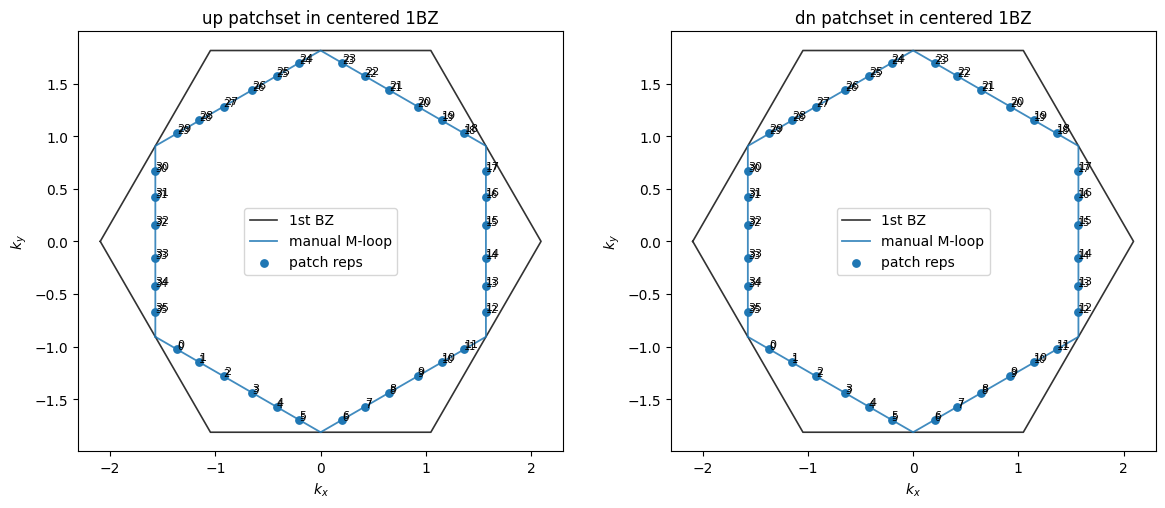

In [99]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = noninteracting.KagomeKaneMeleSOC(dict(t=1.0, l1=0.,l2=0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 7
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"


# ============================================================
# build the final default patchsets for the whole pipeline
# ============================================================
PATCHSETS = build_tr_adapted_patchsets(
    model,
    UP_SLICE,
    DN_SLICE,
    LOCAL_BAND_INDEX,
)

# optional sanity check
defect = pp_triplet_gauge_defect(PATCHSETS)
print("pairing gauge defect max =", np.max(np.abs(defect)))
print("pairing gauge defect fro =", np.linalg.norm(defect))

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()

# Model

CASE = U_only  | U = 10.0  V = 0
T_START, T_STOP, NFREQ, NSTEPS = 5.0 0.05 50 600
NPATCH = 36
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 9.204073558733578
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


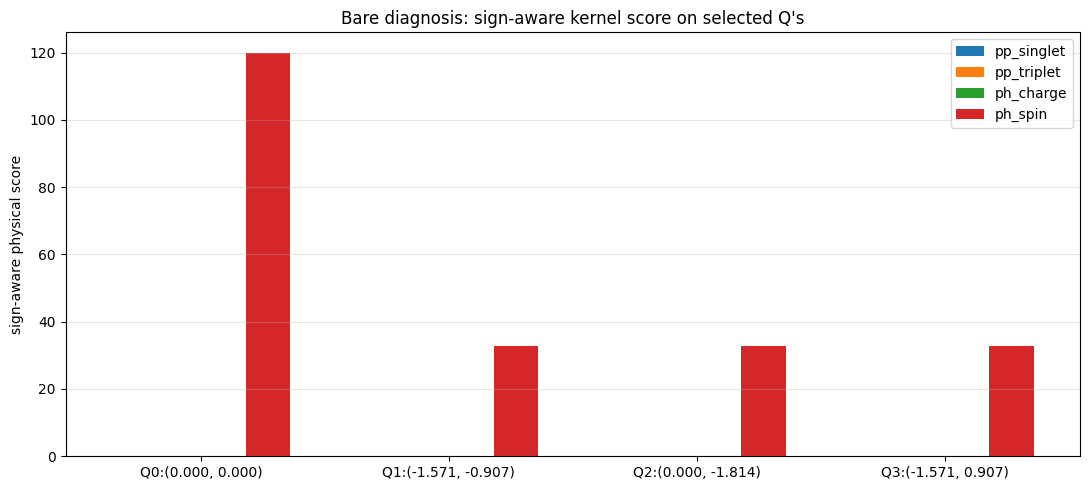


=== bare (initial) physical instability metrics ===


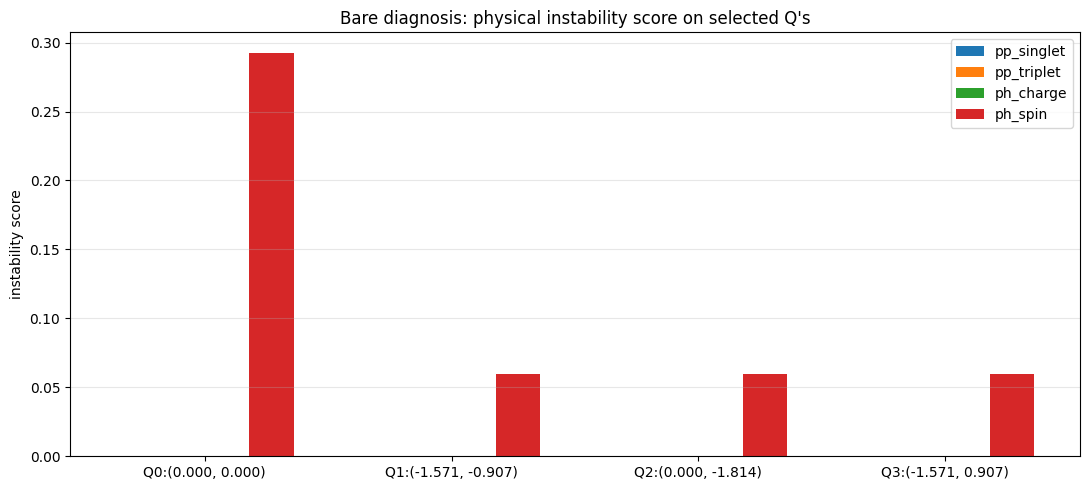

In [18]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "U_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 10., 0
# elif CASE == "V_only":
#     U_TEST, V_TEST = 0.0, 10.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 5.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 ,
    channel_divergence_threshold=1e12,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

# Flow


================ RG FLOW START ================

step=   0 | T=5.000000 | rhs_norm=0.000e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.200e+02
kernel scores: pp_singlet=5.194e-14, pp_triplet=0.000e+00, ph_charge=1.854e-14, ph_spin=1.200e+02
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=2.928e-01
instability: pp_singlet=1.314e-16, pp_triplet=0.000e+00, ph_charge=5.682e-17, ph_spin=2.928e-01
step=   5 | T=4.958681 | rhs_norm=3.787e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.177e+02
kernel scores: pp_singlet=4.280e-01, pp_triplet=2.948e-01, ph_charge=4.441e-01, ph_spin=1.177e+02
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=2.923e-01
instability: pp_singlet=1.380e-03, pp_triplet=1.211e-03, ph_charge=1.696e-03, ph_spin=2.923e-01
step=  10 | T=4.917362 | rhs_norm=3.992e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.155e+02
kernel scores: pp_singlet=8.607e-01, pp_triplet=5.788e-01, ph_charge=8.898e-01, ph_spin=1.155e+02
    lead_instability=ph_spin

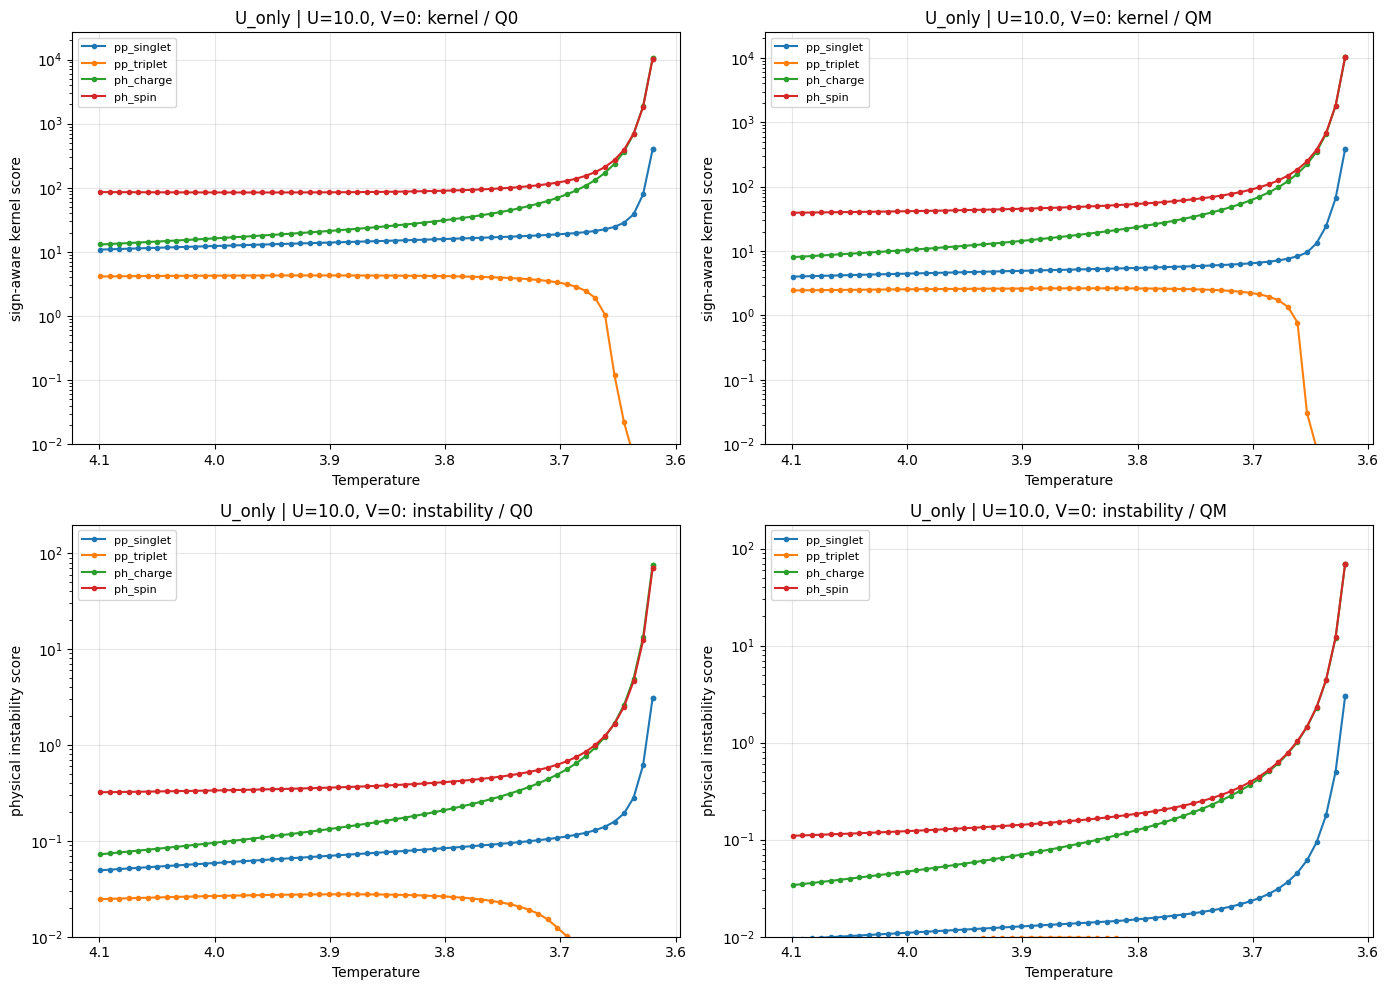

In [20]:
# ============================================================
# Flow run parameters
# ============================================================
PRINT_EVERY = 5               # print every N steps
LAST_N_STEPS_TO_PLOT = 60     # None -> plot all; integer -> only last N steps
PLOT_YLOG = True

# physical instability diagnosis options
PH_BUBBLE_MODE = "patchrep"
PROJECT_PH_CHARGE_Q0_UNIFORM = True
PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT = False


print("\n================ RG FLOW START ================\n")

# history, signaware_history_df, instability_history_df, grouped_plot_df = run_flow_with_tracking(
#     solver,
#     diagnosis_Qs,
#     print_every=PRINT_EVERY,
#     ph_bubble_mode=PH_BUBBLE_MODE,
#     project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
#     project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
# )
history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots = run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    print_every=PRINT_EVERY,
    ph_bubble_mode=PH_BUBBLE_MODE,
    project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
    project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
)

print("\n================ RG FLOW DONE ================\n")
print("history length =", len(history))

last_rec = history[-1]
print("final step =", last_rec.step_index)
print("final T    =", last_rec.temperature)
print("final rhs_norm =", last_rec.rhs_norm)
print("final channel_norm =", last_rec.channel_norm)
print("instability =", last_rec.instability)
print("terminated_early =", last_rec.terminated_early)
print("instability_reason =", last_rec.instability_reason)
print("termination_reason =", last_rec.termination_reason)

# display(signaware_history_df.tail(12))
# display(instability_history_df.tail(12))

plot_flow_group_curves(
    grouped_plot_df,
    last_n_steps=LAST_N_STEPS_TO_PLOT,
    ylog=PLOT_YLOG,
    title_prefix=f"{CASE} | U={U_TEST}, V={V_TEST}",
    ylim=1e-2
)

# Diagnosis

## Instability

Diagnosing step_index = 162
T = 3.661269
rhs_norm = 4.573e+03
channel_norm = 1.685e+02
instability = False
terminated_early = False
instability_reason = None
termination_reason = None

=== sign-aware leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 2.107602689341e+02
chosen  : negative -2.107602689341e+02

=== physical-instability leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 1.243442592989e+00
eval    : 1.243442592989e+00
bubble  : patchrep:bubble_dot_ph(eps_p,eps_p+Q)*measure_p
proj    : nan


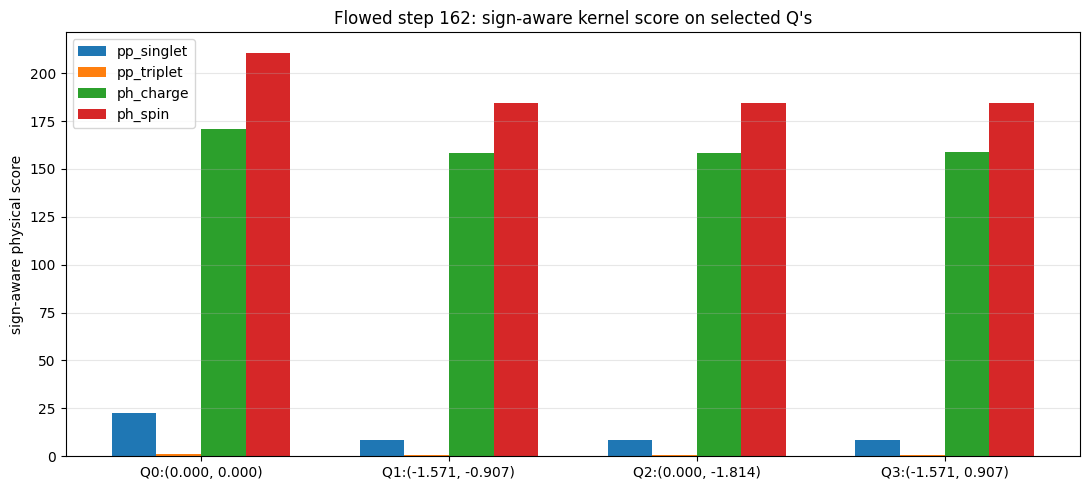

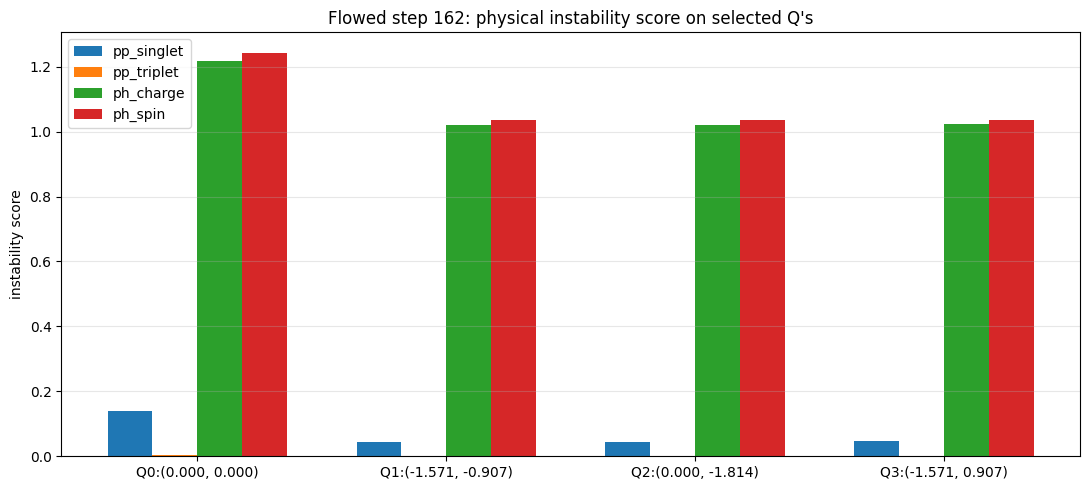

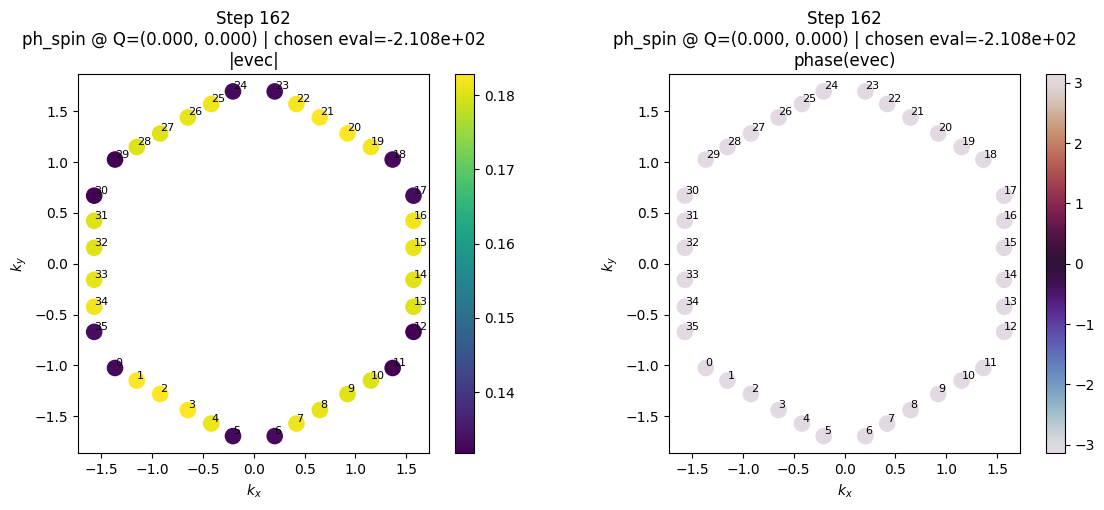

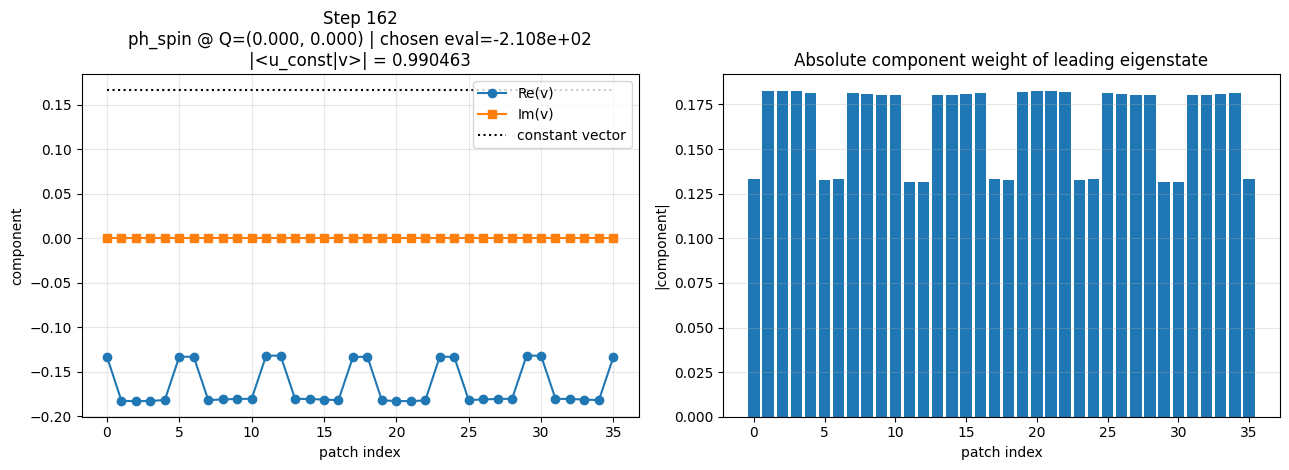


=== leader eigenstate summary ===
channel            : ph_spin
Q                  : (0.000000, 0.000000)
selected eigenvalue: -2.107602689341e+02
kernel dimension   : 36
|<u_const|v>|      : 9.904630590016e-01


In [23]:
# ============================================================
# Diagnose one flowed step
# ============================================================
STEP_SELECTOR = -7  # -1 last step, -2 second last, -3 third last, or exact step index

diagnosis_result = diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    step_selector=STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
)
# Optional: inspect the raw tables
# display(diagnosis_result["df_signaware"].sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(diagnosis_result["df_instability"].sort_values(["Q_index", "channel"]).reset_index(drop=True))

## Form-factor 

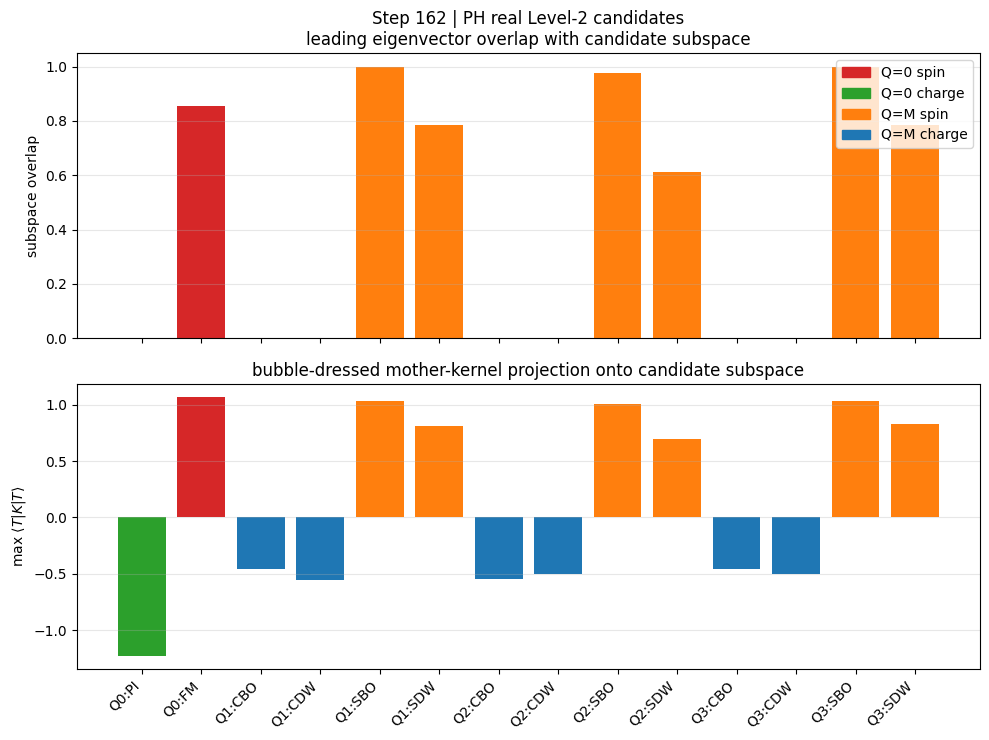

In [25]:
LEVEL2_STEP_SELECTOR = -7

df_l2_ph_real, packs_l2_ph_real = collect_level2_ph_real_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL2_STEP_SELECTOR,
    model=model,
    spin_slice=UP_SLICE,
    local_band_index=LOCAL_BAND_INDEX,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

# display(df_l2_ph_real.sort_values(["Q_index", "channel", "family"]).reset_index(drop=True))

plot_level2_candidate_bars(
    df_l2_ph_real,
    title_prefix=f"Step {df_l2_ph_real['step_index'].iloc[0]} | PH real Level-2 candidates",
)

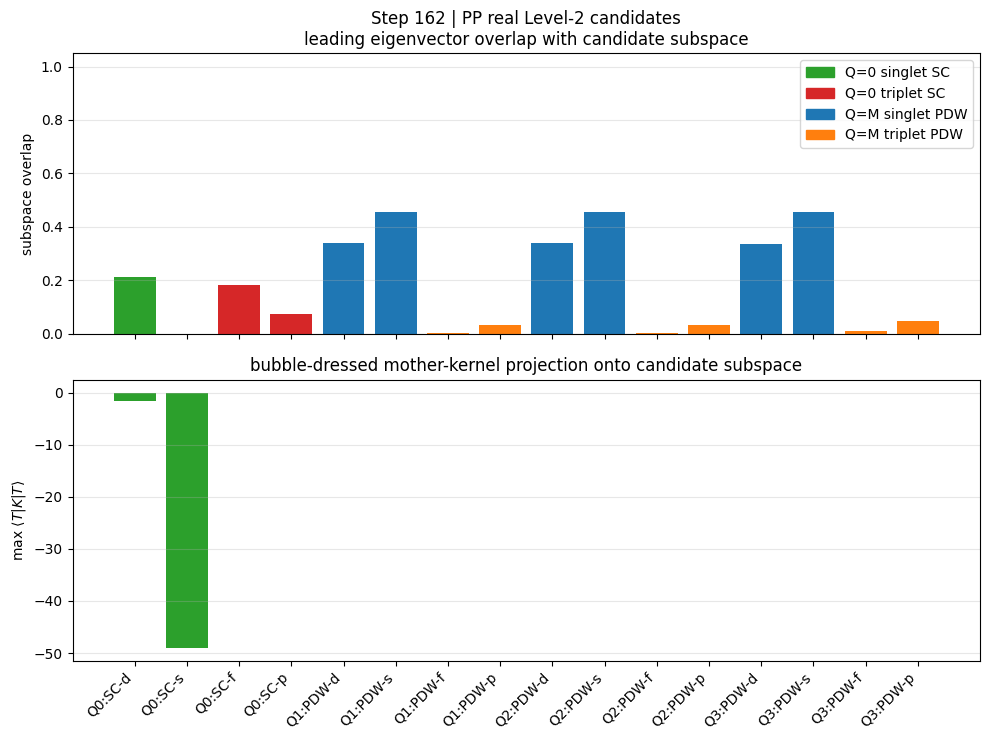

In [26]:
# ============================================================
# Level-2 candidate diagnosis: PP real orders
# ============================================================
LEVEL2_PP_STEP_SELECTOR = -7

df_l2_pp_real, packs_l2_pp_real = collect_level2_pp_real_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL2_PP_STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

# display(df_l2_pp_real.sort_values(["Q_index", "channel", "family"]).reset_index(drop=True))

plot_level2_pp_candidate_bars(
    df_l2_pp_real,
    title_prefix=f"Step {df_l2_pp_real['step_index'].iloc[0]} | PP real Level-2 candidates",
)

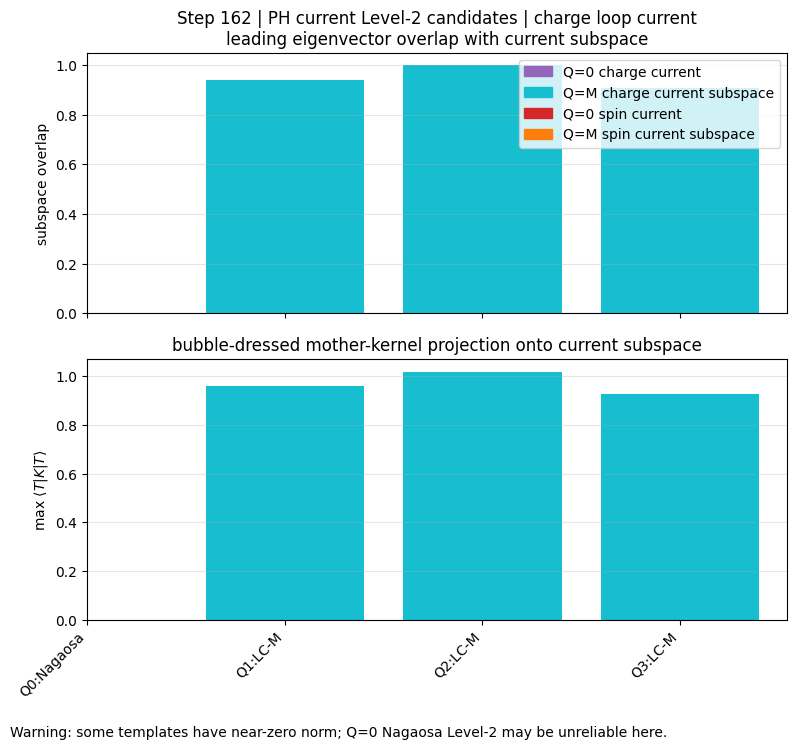

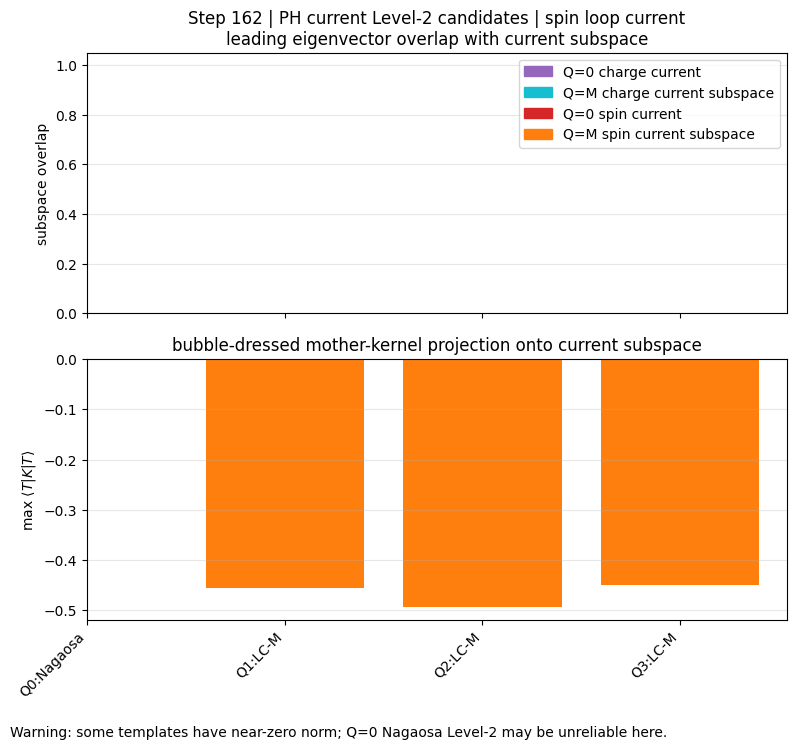

In [27]:
LEVEL2_CURRENT_STEP_SELECTOR = -7

df_l2_ph_current, packs_l2_ph_current = collect_level2_ph_current_candidate_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL2_CURRENT_STEP_SELECTOR,
    model=model,
    spin_slice=UP_SLICE,
    local_band_index=LOCAL_BAND_INDEX,
    band_index=LOCAL_BAND_INDEX,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    use_exact_q0_nagaosa=False,
)

# display(df_l2_ph_current.sort_values(["channel", "Q_index", "family"]).reset_index(drop=True))

plot_level2_ph_current_candidate_bars(
    df_l2_ph_current,
    title_prefix=f"Step {df_l2_ph_current['step_index'].iloc[0]} | PH current Level-2 candidates",
    separate_channels=True,
)

## Expectation

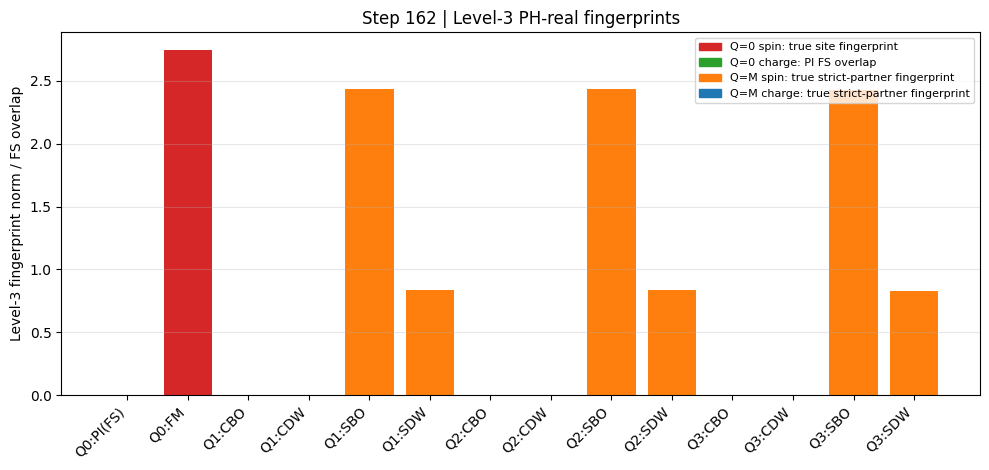

In [72]:
# ============================================================
# Level-3 PH-real fingerprints
# ============================================================
LEVEL3_STEP_SELECTOR = -7

df_l3_ph_real, packs_l3_ph_real = collect_level3_ph_real_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL3_STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    level3_weight_mode="unit",
    include_identity_density=False,
    phase_fix="max_real",
)

# display(
#     df_l3_ph_real[
#         ["Q_index", "channel", "sector", "amplitude_norm",
#          "best_component", "best_abs", "valid_fraction", "note"]
#     ].sort_values(["Q_index", "channel", "sector"]).reset_index(drop=True)
# )

plot_level3_ph_real_fingerprints(
    df_l3_ph_real,
    title_prefix=f"Step {df_l3_ph_real['step_index'].iloc[0]} | Level-3 PH-real fingerprints",
)

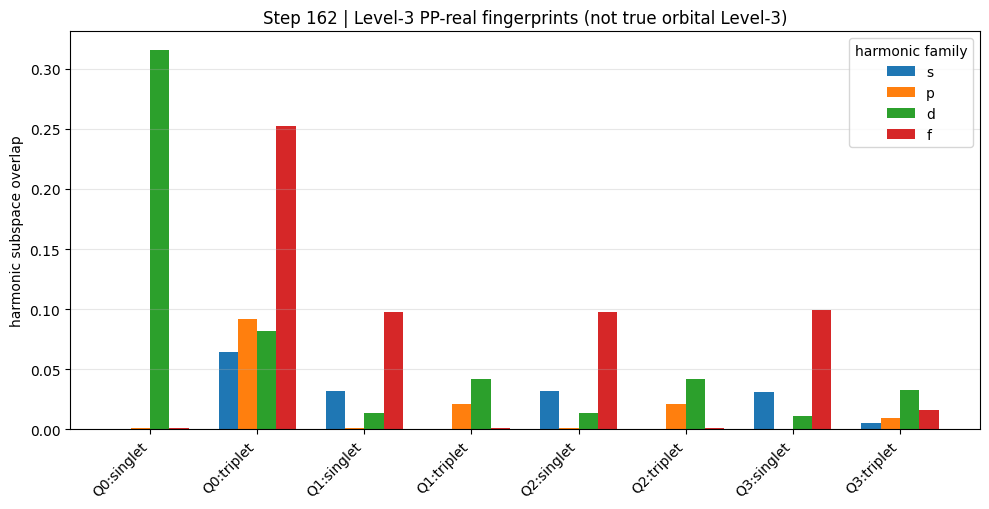

In [74]:
# ============================================================
# Level-3 PP-real fingerprints
# ============================================================
LEVEL3_PP_STEP_SELECTOR = -7

df_l3_pp_real, packs_l3_pp_real = collect_level3_pp_real_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL3_PP_STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    level3_weight_mode="unit",
    phase_fix="max_real",
)

# display(
#     df_l3_pp_real[
#         ["Q_index", "channel", "sector",
#          "s_score", "p_score", "d_score", "f_score",
#          "best_family", "best_score", "note"]
#     ].sort_values(["Q_index", "channel"]).reset_index(drop=True)
# )

plot_level3_pp_real_fingerprints(
    df_l3_pp_real,
    title_prefix=f"Step {df_l3_pp_real['step_index'].iloc[0]} | Level-3 PP-real fingerprints",
)

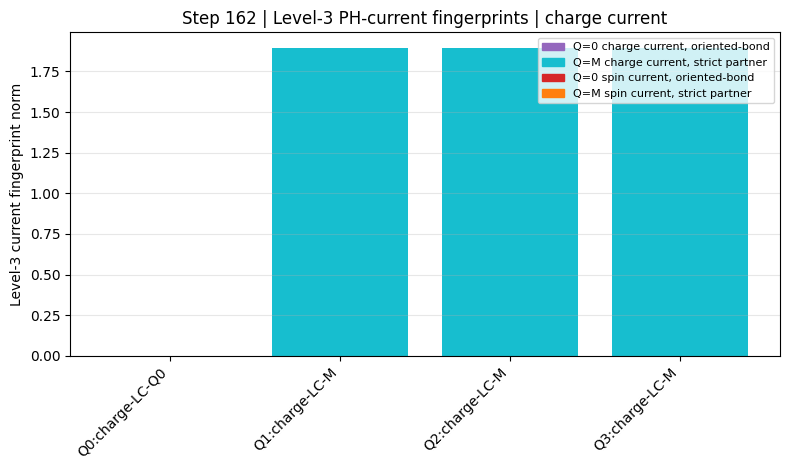

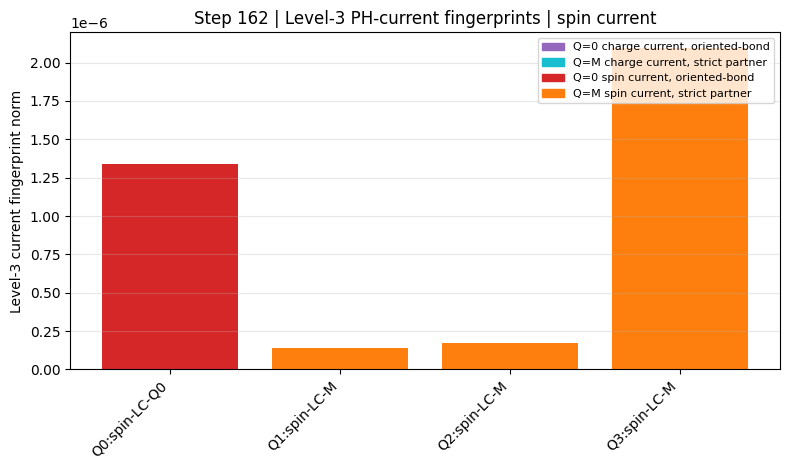

In [70]:
# ============================================================
# Level-3 PH imaginary/current fingerprints
# ============================================================
LEVEL3_CURRENT_STEP_SELECTOR = -7

df_l3_ph_current, packs_l3_ph_current = collect_level3_ph_current_fingerprints(
    solver,
    history,
    diagnosis_Qs,
    step_selector=LEVEL3_CURRENT_STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    level3_weight_mode="unit",
    phase_fix="max_real",
)

# display(
#     df_l3_ph_current[
#         ["Q_index", "channel", "sector", "amplitude_norm",
#          "best_component", "best_abs", "valid_fraction", "note"]
#     ].sort_values(["channel", "Q_index"]).reset_index(drop=True)
# )

plot_level3_ph_current_fingerprints(
    df_l3_ph_current,
    title_prefix=f"Step {df_l3_ph_current['step_index'].iloc[0]} | Level-3 PH-current fingerprints",
    separate_channels=True,
)

## Time-Serie

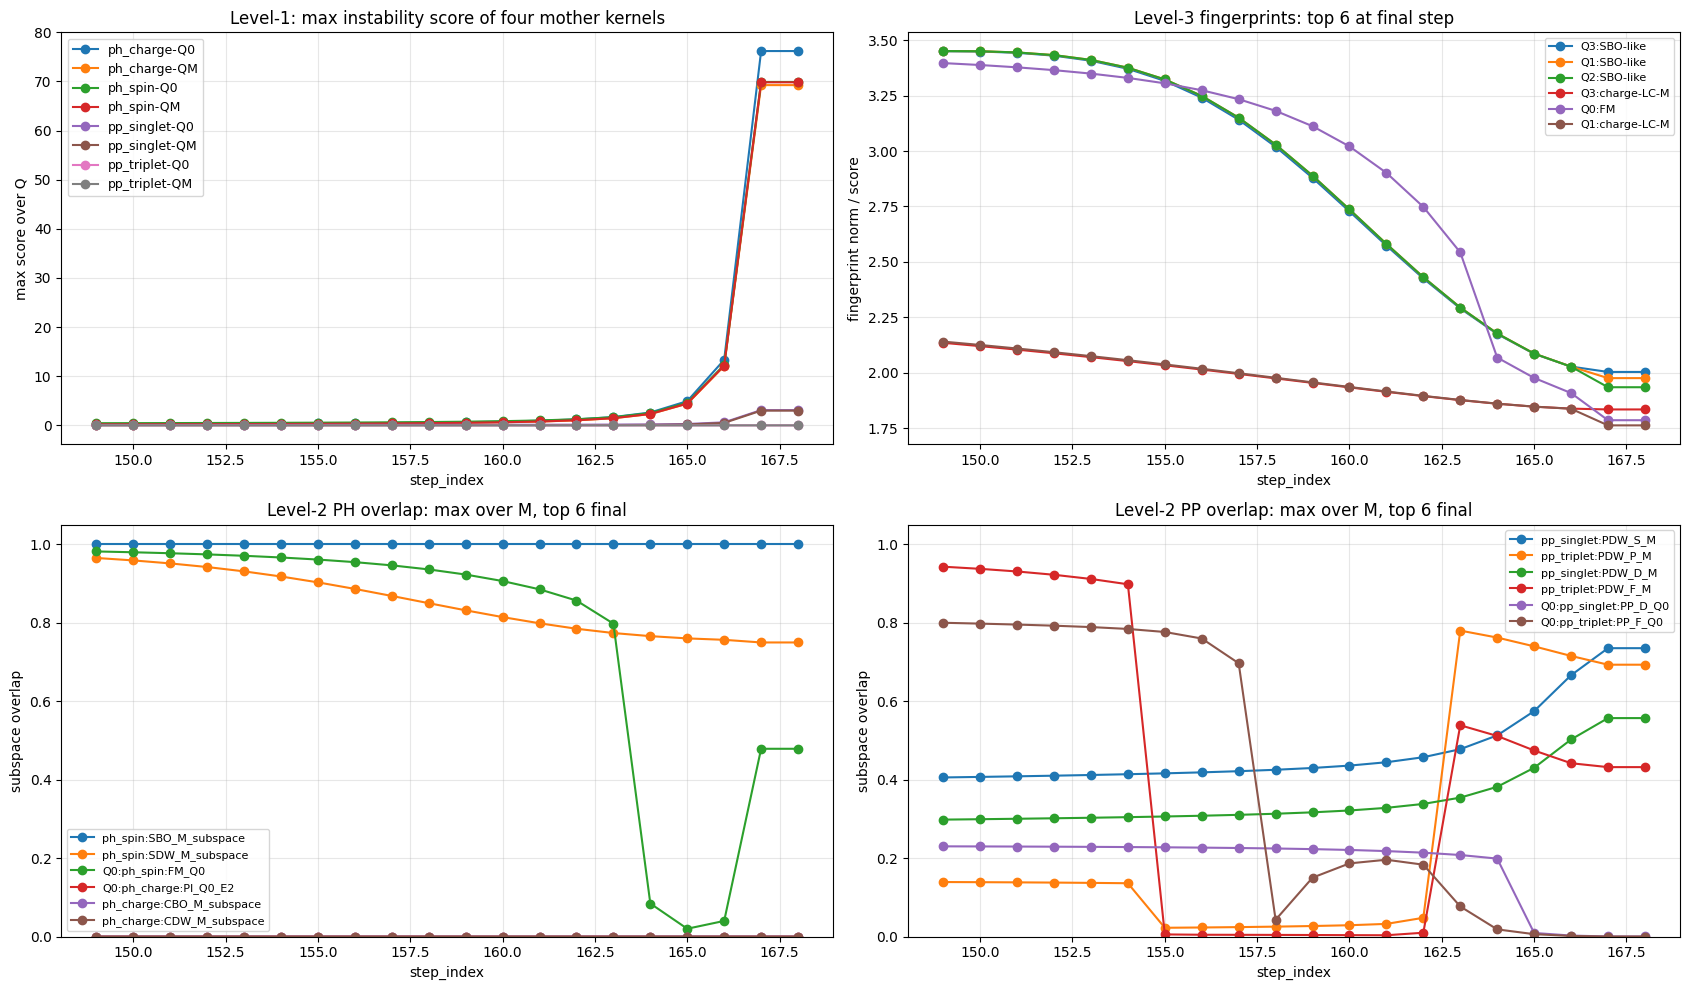

In [33]:
# ============================================================
# Overall last-N time-series diagnosis
# ============================================================
LAST_N_TIMESERIES_STEPS = 20

ts_overall = collect_overall_timeseries_diagnosis(
    solver,
    history,
    diagnosis_Qs,
    last_n_steps=LAST_N_TIMESERIES_STEPS,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

plot_overall_timeseries_diagnosis(
    ts_overall,
    top_n_l3=6,
    x_axis="step_index",   # or "T"
)

## dim-2 Leading Subspace

In [35]:
# ============================================================
# Print and plot first 6 eigenvalues of four instability kernels
# ============================================================
SPECTRA_STEP_SELECTOR = -7

df_level1_spectra = inspect_level1_instability_spectra(
    solver,
    history,
    diagnosis_Qs,
    step_selector=SPECTRA_STEP_SELECTOR,
    top_n=6,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

display(
    df_level1_spectra[
        ["Q_index", "channel", "lambda_1", "lambda_2", "lambda_3",
         "lambda_4", "lambda_5", "lambda_6", "gap_12", "rel_gap_12"]
    ].sort_values(["Q_index", "channel"]).reset_index(drop=True)
)

# plot_level1_spectra_bars(
#     df_level1_spectra,
#     top_n=6,
#     title_prefix=f"Step {df_level1_spectra['step_index'].iloc[0]} | first 6 eigenvalues",
# )

,Q_index,channel,lambda_1,lambda_2,lambda_3,lambda_4,lambda_5,lambda_6,gap_12,rel_gap_12
0,0,ph_charge,1.217467,1.215794e+00,1.215776e+00,1.139675e+00,1.138186e+00,1.138172e+00,0.001673,0.001374
1,0,ph_spin,1.243443,1.237946e+00,1.236858e+00,1.085372e+00,1.084564e+00,1.081566e+00,0.005496,0.004420
2,0,pp_singlet,0.138922,1.387397e-01,1.296807e-01,4.711696e-02,4.689181e-02,3.661291e-02,0.000182,0.001313
3,0,pp_triplet,0.003314,2.080538e-03,2.080103e-03,1.560429e-03,1.370654e-03,1.369924e-03,0.001234,0.372257
4,1,ph_charge,1.020546,9.966919e-01,4.879089e-01,4.875796e-01,4.429400e-01,4.361877e-01,0.023854,0.023374
5,1,ph_spin,1.035391,9.962757e-01,5.394493e-01,4.799459e-01,4.496199e-01,4.351753e-01,0.039115,0.037778
6,1,pp_singlet,0.045062,3.432480e-02,2.252455e-02,2.005638e-02,1.356834e-02,9.900789e-16,0.010737,0.238276
7,1,pp_triplet,0.002176,8.477522e-11,4.597742e-11,4.711562e-13,1.378571e-13,2.936831e-14,0.002176,1.000000
8,2,ph_charge,1.020528,9.966737e-01,4.879077e-01,4.875784e-01,4.429388e-01,4.361865e-01,0.023854,0.023374
9,2,ph_spin,1.035373,9.962575e-01,5.394481e-01,4.799448e-01,4.496188e-01,4.351743e-01,0.039115,0.037779


# Debug